# Sigmoid fitting and T50 — EGF temporal dynamics

Fit a **sigmoid** to each phosphosite's EGF time course and extract **T50**, the time the site
takes to reach half of its final level. The `full` timepoint is excluded (it is a biological
control, not a point on the post-stimulation clock) and `starve` is the reference.

## The question this notebook answers first

**Not every curve is a sigmoid.** A logistic is strictly monotone — it has no interior
extremum — so it structurally *cannot* represent a response that rises and then falls. EGF
signalling is mostly transient, precisely because of the negative feedback loops this project
is about.

Fitting a sigmoid to a transient site does not raise an error. The optimiser returns a
plausible-looking, **wrong** T50: it either fits the rising limb and treats the decline as
residual, compromises through the middle (T50 pushed late, amplitude shrunk), or — for a site
that returns fully to baseline — fits a flat curve and silently reclassifies the site as
non-responsive.

So the first deliverable is the **census**: how many sites may a sigmoid legitimately be fitted
to? Only then are the fits run, and only on those sites.

## What is being fitted

With `x = log10(t + 1)`:

$$y(x) = y_0 + A\left[\sigma\big(k(x - x_{50})\big) - \sigma(-k\,x_{50})\right], \qquad \sigma(u)=\frac{1}{1+e^{-u}}$$

The bracketed term vanishes identically at `x = 0`, which is what **anchored** means, and $y_0$
is the level the curve starts from.

### ⚠️ Two scales, and the fits do not happen on the one you would expect

This notebook **classifies on `log2:FC` and fits on `log2:mean`.** That split is deliberate.

`WT_log2:FC_EGF_starve` is identically 0, because the fold change is *defined* relative to
starve. Fitting on that scale means asserting $y_0 = 0$ **exactly** — the baseline is known
without error — and dropping the starve replicates from the fit entirely. That is the **hard
anchor**, and it has two problems:

1. **The errors are correlated.** Every `log2:FC` timepoint contains the same $-\overline{\text{starve}}$
   term, so $\mathrm{Cov}(FC(t_i), FC(t_j)) = \mathrm{Var}(\overline{\text{starve}}) > 0$ for
   *every* pair. The fit weights by `1/SEM`, a **diagonal** matrix, which assumes independence.
   On the mean scale the errors are independent by construction and that weighting becomes
   correct rather than approximate.
2. **The starve replicates do no work**, and "is the 2-min point above baseline, or level, or
   below it?" is not a question a fit with a fixed baseline can answer.

So the fits use the **soft anchor**: $y_0$ free, on `log2:mean`, where starve is a measurement
carrying its own SEM.

**The degrees-of-freedom ledger is neutral** — this is the crux, and the reason the change is
affordable at all. Fitting the mean adds one observation *and* one parameter:

| scale | k | observations | free parameters | lack-of-fit df |
|---|---|---|---|---|
| `log2:FC`, hard anchor | free | 5 (starve dropped) | A, k, x50 = 3 | **2** |
| `log2:FC`, hard anchor | fixed | 5 | A, x50 = 2 | **3** |
| `log2:mean`, soft anchor | free | 6 (starve is real) | y0, A, k, x50 = 4 | **2** |
| `log2:mean`, soft anchor | fixed | 6 | y0, A, x50 = 3 | **3** |

⚠️ **This does not make the fit more accurate, and must not be reported as if it did.** It is a
change in *statistical honesty*, the same category as the log-time argument below: not a better
fit, a better parameterisation. The validation section measures exactly how little moves.

**Classification stays on `log2:FC`** — it is model-free, the class definitions and the census
are FC-based, and swapping in a mean-scale SEM would shrink the noise band `delta` (no starve
term) and silently move the headline percentage for reasons unrelated to any of this.

In practice **k is not estimated at all.** The steepness turns out not to be identifiable on
this timepoint grid (the section "the steepness cannot be estimated from this design"), so it is
fixed by convention and only the baseline, amplitude and timing are fitted.

### 📖 Explainer 0 — read this first: what this notebook is doing

*Every cell titled **📖 Explainer** exists to make this notebook readable without a background in
curve fitting or statistics. They define the terms the rest of the notebook uses and nothing in them
runs. Skip them once they are familiar.*

#### The data, as the fitting code sees it

After preprocessing, one **phosphosite** (one phosphorylated S/T/Y residue on one protein) is one
row, and its EGF time course is six numbers:

| `starve` | 2 min | 5 min | 10 min | 15 min | 90 min |
|---|---|---|---|---|---|
| reference | ... | ... | ... | ... | ... |

Two things about those six numbers matter for everything below:

1. **Each is a mean of 3–4 replicates**, so each also has an *uncertainty* attached — the same
   number measured again would come out slightly different. That uncertainty is not decoration: it
   decides which sites are called responsive and how hard each point pulls on the fitted curve.
2. **`starve` is the reference**, i.e. time zero. `full` (cells in complete medium) is a separate
   biological control and is dropped — it is not a point on the post-stimulation clock.

So the whole notebook operates on a matrix of shape `(n_sites, 6)` plus a second matrix of the same
shape holding the uncertainties.

#### Two ways to summarise a temporal profile

- **Model-free descriptors** (`src/response_shapes.py`). Read numbers straight off the six points:
  where the maximum is, how big it is, how much of it survives to 90 min. No assumption about the
  shape of the curve, no optimiser, always available — but the answers are **quantised to the
  sampling grid**. "Peak time" can only ever be one of 2, 5, 10, 15 or 90 min, so a site that peaks
  at 6.5 min and one that peaks at 9.5 min both report "5" or both report "10".
- **A parametric model** (`src/curve_fitting.py`). Assume the profile follows a specific
  mathematical formula with a few adjustable numbers (**parameters**) in it, and find the parameter
  values that make the formula pass as close as possible to the six observed points. The reward is
  that the parameters are *continuous*: a fitted timing of 6.5 min is expressible even though 6.5
  was never sampled. The cost is that the assumed formula might be the wrong shape for the site,
  and a wrong-shape fit still returns confident-looking numbers.

This notebook does both, in that order, and uses the first to decide which sites are allowed into
the second.

#### What "fitting a curve" actually means, mechanically

1. Pick a formula, here a **sigmoid** (an S-shaped curve — Explainer 1), with 3–4 unknown numbers in it.
2. For a given guess at those numbers, compute what the formula predicts at 2, 5, 10, 15, 90 min.
3. Compare prediction to observation. Each gap is a **residual**.
4. Combine the residuals into one score, the **cost**: the sum of squared residuals, each divided by
   that point's uncertainty first, so well-measured points count more.
5. Let an **optimiser** (`scipy.optimize.least_squares`) push the numbers around until the cost stops
   getting smaller. The parameter values at that point are "the fit".

There is no formula that hands you the answer — step 5 is an iterative numerical search, which is
why terms like "restarts", "local minimum" and "convergence" appear later.

#### The pipeline of this notebook, and what each stage decides

| stage | question it answers | output |
|---|---|---|
| profile matrices | what are the six numbers, and how noisy is each? | `values`, `sem_fc`, `values_mean`, `sem_fit` |
| descriptors | model-free summary of every site | `descriptors` |
| **shape census** | *may* a sigmoid be fitted to this site at all? | `_shapes`, `sigmoid_legitimate` |
| steepness profiling | can the data determine how steep the S is? (no) | `k_profile` → `FIXED_K` |
| the fit | for the allowed sites, when does the response reach half its final level? | `fits`, `t_half_min` |
| quality gates | is this particular fit trustworthy enough to report? | `fit_ok` |
| diagnostics | are the uncertainties on those answers honest? | bootstrap, leverage, k-sensitivity |

**T50** — the headline output — is the time at which a site reaches half of its final level. It is
a *timing* measure, deliberately independent of how large the response is, so that "which substrates
respond first" can be asked separately from "which respond most".


### 📖 Explainer 1 — the model: sigmoid, its parameters, T50, log-time, and "anchored"

#### The logistic function

Everything is built from one function, the **logistic** (or **sigmoid**, "S-shaped"):

$$\sigma(u) = \frac{1}{1 + e^{-u}}$$

Its properties, which are the reason it is used:

- it is **bounded**: $\sigma(u) \to 0$ as $u \to -\infty$ and $\sigma(u) \to 1$ as $u \to +\infty$;
- it is **monotone**: always increasing, never turning around. **This is the crucial limitation.**
  A logistic has no interior maximum, so it structurally cannot describe a site that rises and then
  falls back — which most EGF responses do;
- it is **smooth and symmetric** about its midpoint: $\sigma(0) = 0.5$;
- the transition is effectively local — it goes from 10% to 90% of its range over an interval of
  width $4.4/k$ once the steepness $k$ is introduced.

#### The model fitted here

With `x` a transformed time axis (below) the model is

$$y(x) = y_0 + A\left[\sigma\big(k(x - x_{50})\big) - \sigma(-k\,x_{50})\right]$$

Four parameters, each with a distinct visual meaning:

| parameter | in words | what changes if you increase it |
|---|---|---|
| $y_0$ | **baseline** — the level the curve starts from at $t = 0$ | the whole curve slides up |
| $A$ | **amplitude** — how far the curve travels from baseline. Negative for a site that goes *down* | the curve becomes taller |
| $k$ | **steepness** — how abruptly the transition happens on the `x` axis | the S becomes sharper, tending to a step |
| $x_{50}$ | **inflection point** — the `x` at which the curve is steepest, i.e. *when* the transition happens | the whole transition shifts later |

$A$, $k$, $x_{50}$ are near-independent in meaning: *how much*, *how sharply*, *when*. That
separation is the whole reason for using a parametric model instead of eyeballing the six points.

Two derived quantities are computed from the fitted parameters (`src/curve_fitting.py`):

- **`plateau`** $= A\,[1 - \sigma(-k x_{50})]$ — the level the curve settles at as $t \to \infty$,
  measured *relative to the baseline*, so it stays a log2 fold change and is comparable across sites
  and across the two scales. Signed: positive = induced, negative = suppressed.
- **`t_half_min`** (**T50**) — the time at which the curve reaches half of `plateau`. The amplitude
  $A$ cancels out of the algebra, so T50 is a pure timing number: an up-regulated and a
  down-regulated site with identical kinetics get identical T50.

⚠️ The fit table also carries **`t50_min`** $= 10^{x_{50}} - 1$, which is the *inflection* time, not
the half-response time. They differ slightly because of the anchoring offset (`t_half_min` is the
later of the two whenever $x_{50} > 0$). **`t_half_min` is the one to report**; it is what the
quality gates and every plot use.

#### Why the time axis is $x = \log_{10}(t+1)$ and not minutes

The design samples 2, 5, 10, 15 and 90 min: dense early, one point far away. On a raw-minute axis
the 90 min point sits alone at the far end of the x range and dominates the fit (see Explainer 4,
*leverage*). Taking a logarithm compresses the long gap and spreads out the early points, so the
five samples end up roughly evenly spaced — which is what a fitting procedure implicitly assumes.

- The `+1` exists so that $t = 0$ (starve) maps to $x = 0$ rather than to $-\infty$. It is a
  convention, not a correction; on this grid it changes nothing biologically.
- $k$ is therefore a steepness **per unit of $\log_{10}$ time**, not per minute. A $k$ of 10 means
  the 10→90% transition takes $4.4/10 = 0.44$ log10-units ≈ a factor of 2.8 in time.
- ⚠️ Log-time is **not a better fit** — the residuals come out essentially the same. It is a better
  **parameterisation**: the same quality of fit, expressed in numbers that are stable, comparable
  between sites and not hostage to one measurement.

#### "Anchored": the two versions of the baseline

The bracketed term $[\sigma(k(x - x_{50})) - \sigma(-k x_{50})]$ is constructed so that it is
**exactly zero at $x = 0$** — the second term is just the value of the first at $x = 0$, subtracted
off. So $y(0) = y_0$ always, for any parameter values. That is what **anchored** means: the curve is
pinned at time zero.

Where the two scales differ is what $y_0$ is allowed to be:

| | **hard anchor**                                                                                                                                                                                                                                                                                                                                                                                          | **soft anchor** |
|---|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---|
| fitted on | `log2:FC` (fold change vs starve)                                                                                                                                                                                                                                                                                                                                                                        | `log2:mean` (log2 intensity) |
| baseline | forced to $y_0 = 0$                                                                                                                                                                                                                                                                                                                                                                                      | $y_0$ is a fitted parameter |
| starve point | not an observation — it is 0 *by definition*, so it is dropped from the residuals (the fact that it is dropped does not mean anything because it is being fixed to 0, which in this case would be the same as not removing it, this is weird concept and i dont fully understand why it removes it and then fix it 0 0, removing an observation (residual) but leaving the same value as fixed (the "0") | a real measurement with its own error, kept |
| free parameters (with `k` fixed) | $A, x_{50}$                                                                                                                                                                                                                                                                                                                                                                                              | $y_0, A, x_{50}$ |
| observations | 5                                                                                                                                                                                                                                                                                                                                                                                                        | 6 |
| function | `anchored_sigmoid`                                                                                                                                                                                                                                                                                                                                                                                       | `soft_anchored_sigmoid` |

The intro cell argues for the soft anchor. The reason is *not* accuracy — the validation section
below measures how little the answers move — it is that fold changes at different timepoints all
contain the same subtracted starve mean, so their errors are **correlated**, while the weighting
scheme used by the optimiser assumes they are independent. On the mean scale that assumption is
true, because different timepoints are different measurements.

#### A worked example, to make the numbers concrete

Take $y_0 = 0$, $A = 1.5$, $k = 10$, $x_{50} = \log_{10}(9) = 0.954$ (so the inflection sits at
$t = 10^{0.954} - 1 = 8$ min):

- at $t = 0$: $y = 0$ by construction;
- at $t = 90$ min ($x = 1.96$): $\sigma(10 \times 1.01) \approx 1$, so $y \approx$ `plateau` ≈ 1.5,
  i.e. a 2^1.5 ≈ 2.8-fold increase over starve;
- T50 ≈ 8 min — the fit says the site is halfway to its final level 8 minutes after stimulation.

The sanity-check cell below generates exactly this curve with realistic noise added and checks the
fitting code gets 8 min back out.


### 📖 Explainer 2 — uncertainty: SD, SEM, error propagation, weights, and variance moderation

Nearly every design decision in this notebook is really a statement about measurement error, so the
vocabulary is worth pinning down.

#### Replicates, SD and SEM

The experiment measures each condition × timepoint in **4 biological replicates** (3 for some
sites, where a replicate was not quantified). For one site at one timepoint:

- the **mean** is what gets stored as `log2:mean` and is used as "the" value;
- the **standard deviation (SD)** measures how much the individual replicates scatter around that
  mean — a property of the *measurement process*, and it does not shrink by measuring more;
- the **standard error of the mean (SEM)** $= \mathrm{SD}/\sqrt{n}$ measures how uncertain *the mean
  itself* is — and it does shrink with more replicates.

The distinction matters twice here: the **noise band** that decides whether a site responded is
built from SEMs (it is a question about the means), while `SIGMA`, the noise scale the RMSE gate
compares against, is a **SD** (it is a question about how far individual points can legitimately sit
from the curve). The code converts between them with $\mathrm{SD} = \mathrm{SEM}\times\sqrt{n}$.

#### Variance, and why fold changes are noisier than means

**Variance** is SD². It is the quantity that *adds* when independent things are combined:

$$\mathrm{Var}(X - Y) = \mathrm{Var}(X) + \mathrm{Var}(Y) \quad\text{(for independent } X, Y)$$

A fold change is a difference of two means, $FC(t) = \overline{y}(t) - \overline{y}(\text{starve})$,
so its uncertainty carries **both** terms:

$$\mathrm{SEM}_{FC}(t) = \sqrt{\frac{\mathrm{Var}(t)}{n_t} + \frac{\mathrm{Var}(\text{starve})}{n_{\text{starve}}}}$$

That is **error propagation**, and it is the reason the FC-scale SEMs printed below are the larger
ones (median ≈ 0.113 against ≈ 0.082 on the mean scale) — roughly a factor $\sqrt{2}$. It is also
why the two scales need two different formulas rather than a patched column: `per_site_sem(target=)`
switches the formula.

The same fact has a second consequence, which is the statistical argument for the soft anchor: every
fold-change timepoint contains the *same* $-\overline{\text{starve}}$ term, so any two of them are
**correlated** (they share an error). Weighting by `1/SEM` treats each point as carrying its own
independent error — true on the mean scale, only approximately true on the FC scale.

#### Weighted least squares

The optimiser minimises

$$\chi^2 = \sum_i \left(\frac{y_i - f(x_i)}{\mathrm{SEM}_i}\right)^2$$

Each residual is divided by that point's own SEM before squaring, so a point measured to ±0.05
constrains the curve four times as hard as one measured to ±0.20. Two useful readings of the same
formula: the residuals are expressed in "number of standard errors", and the fit is a
**maximum-likelihood** estimate under the assumption that measurement noise is Gaussian with known
per-point scale.

#### Degrees of freedom — two different meanings, both used here

The phrase means "number of independent pieces of information", but it appears in two roles:

1. **Of a variance estimate.** An SD computed from $n$ replicates has $d = n - 1$ df — 3 for four
   replicates, 2 for three. Low df means the SD is *itself* a very noisy number. (Intuition: with
   three replicates that happen to land close together, the estimated SD is far too small, and any
   test using it will be overconfident.)
2. **Of a model fit.** With $n$ observations and $p$ fitted parameters, $n - p$ df are left over to
   judge the fit with. This is the **lack-of-fit df** — see Explainer 3. Six points and three
   parameters leaves 3; six points and five parameters leaves 1; six and six leaves 0, at which
   point the model passes exactly through the data and cannot be wrong, which means it also cannot
   be tested. Half the design decisions in this notebook are about protecting this number.

#### Variance moderation (empirical-Bayes shrinkage)

Problem: with 3–4 replicates each site's SD has 2–3 df and is therefore unreliable, but the whole
classification depends on a **per-site** noise band. Solution: pull each site's variance towards the
typical variance at that timepoint, on the reasoning that a site whose SD looks extreme is more
likely to have been unlucky than to be genuinely extreme. (OBJECTION:  why to do this? if a site has extreme SD, shouldn't it be treated as a too noissy point to use? I gues the reasso to do what you are saying is that if we would drop those sites with extreme SD we would be dropping too many sites. Am I right?)

$$s^2_{\text{moderated}} = \frac{d_0\, s^2_{\text{prior}} + d\, s^2_{\text{site}}}{d_0 + d},
\qquad d = n - 1$$

- $s^2_{\text{prior}}$ is the median variance across all sites at that timepoint;
- $d_0$ is `PRIOR_DF`, the weight given to that shared estimate expressed **in pseudo-replicates**;
- the prior's share of the answer is $d_0/(d_0 + d)$.

Concretely at $n = 4$ ($d = 3$): `prior_df = 1` gives the prior 25%, `prior_df = 2` gives 40%,
`prior_df = 4` gives 57%. At $n = 3$ those become 33%, 50%, 80%. This is the *idea* behind limma's
empirical-Bayes moderation (Smyth 2004), simplified: limma estimates the prior and its weight from
the data, here the prior is the observed median and the weight is a parameter, which is why the
notebook sweeps it rather than trusting a default.

**Terminology:** *prior* = what you believe before looking at this particular site; *shrinkage* =
moving an individual estimate towards a shared one; *empirical Bayes* = building the prior from the
dataset itself rather than from outside knowledge.


### 📖 Explainer 3 — how a fit is judged: RSS, RMSE, chi-square, p-values, FDR, BIC

Five numbers do all the work in this notebook. They answer different questions and it is easy to
conflate them.

#### 1. `rss` and `rmse` — how far the curve is from the points

- **Residual**: observed − predicted, at one timepoint.
- **RSS** (residual sum of squares): $\sum_i r_i^2$. Unweighted here.
- **RMSE** (root mean squared error): $\sqrt{\mathrm{RSS}/n}$ — the typical size of a residual, in
  the units of the data (log2 units). Directly interpretable: `rmse = 0.13` means the curve
  typically misses the points by 0.13 log2 units ≈ 9%.

RMSE alone cannot say whether a fit is *good*, because it does not know how noisy the data are.
0.13 is excellent if the measurement noise is 0.20 and terrible if it is 0.02. That is why the gate
is `rmse < SIGMA`: **the fit must track the data to within measurement error**.

#### 2. `chi2` — the same thing, but in units of the measurement error

$$\chi^2 = \sum_i \left(\frac{r_i}{\mathrm{SEM}_i}\right)^2$$

This is the quantity the optimiser minimises. Each term is "how many standard errors is this point
away from the curve, squared". The useful calibration: **if the model is correct, each residual is
about ±1 SEM, so each term contributes about 1, and $\chi^2 \approx$ df.**

- $\chi^2 \approx$ df → the model describes the data as well as the noise allows;
- $\chi^2 \gg$ df → the model is missing something real (a wrong shape);
- $\chi^2 \ll$ df → suspiciously good, usually meaning the SEMs are overstated.

#### 3. `p_lof` — the lack-of-fit test, and its direction

The **p-value** of any test is: *if the null hypothesis were true, how often would I see a
statistic at least this extreme by chance alone?* Small p = the data are hard to reconcile with the
null.

Here the null is **"the sigmoid is the right shape for this site"**, and the statistic is $\chi^2$
compared to a chi-square distribution with `df_lof` = (points − free parameters) degrees of freedom.

⚠️ **The direction is the opposite of the usual one.** For this test a *large* p is the good outcome
— it means the misfit is no bigger than the noise. The gate is `lof_ok = p_lof > 0.05`. Note also
what a non-rejection is and is not: it is "no detectable evidence against the sigmoid", not proof
that the sigmoid is correct. With 3 df there is not much power, which is exactly why the shape
census runs *before* the fit instead of relying on this test to catch bad shapes.

#### 4. `p_vs_flat` — comparing two models, and the FDR

Separate question: not "does the curve fit" but **"is this site responding at all, or would a flat
line have done just as well?"**

The two models are **nested** — the flat line is the sigmoid with the amplitude set to zero — which
licenses a **chi-square difference test**:

$$\Delta\chi^2 = \chi^2_{\text{flat}} - \chi^2_{\text{sigmoid}} \;\sim\; \chi^2_{\;(p_{\text{sig}} - p_{\text{flat}})}$$

A bigger model always fits at least as well, so $\Delta\chi^2 > 0$ always; the test asks whether the
improvement is *larger than the improvement you would get for free* from adding parameters. Here a
small p is the good outcome (`responsive = fdr_vs_flat < 0.05`).

Two subtleties the code handles explicitly:

- **What "flat" is depends on the scale.** On `log2:FC`, flat means the exact line $y = 0$ — zero
  free parameters, because fold change is defined relative to starve. On `log2:mean`, flat means a
  *fitted* constant $y = y_0$ — one free parameter, since a site sitting flat at 18.4 log2 units is
  not responsive but would look wildly responsive against a $y = 0$ null. Sanity check 5 at the top
  of the notebook demonstrates this on 400 pure-noise sites.
- **Why chi-square and not an F-test.** An F-test estimates the noise level *from the residuals*.
  With 2–3 residual df that estimate is so imprecise that the test loses essentially all power —
  measured here: the sigmoid cuts the median chi-square by a factor of four, yet the F-test returns
  a median p of 0.37 and rejects nothing. The chi-square test is available precisely because the
  noise level is already known independently, from the replicates.

**Multiple testing and FDR.** Testing ~3000 sites at p < 0.05 would produce ~150 false positives
from noise alone. The **false discovery rate (FDR)** controls the expected *proportion of the calls
you make* that are wrong, and the **Benjamini–Hochberg** procedure converts a list of p-values into
FDR-adjusted values (**q-values**). "FDR < 0.05" means: of the sites called responsive, about 5% are
expected to be false. This is a deliberately gentler criterion than controlling the chance of *any*
false positive (Bonferroni), which would be far too strict for thousands of sites.

#### 5. `bic_sigmoid` / `bic_flat` — model choice without a p-value

The **Bayesian Information Criterion** scores a model as misfit plus a penalty for complexity,
$\mathrm{BIC} = n\log(\chi^2/n) + p\log n$. Lower is better; a gap of >10 is conventionally strong
evidence. It is reported alongside the test as a second opinion that does not depend on choosing a
significance threshold.


### 📖 Explainer 4 — identifiability, standard errors, bootstrap, censoring, correlation, leverage

The remaining vocabulary, all of it about *how much to trust a fitted number*.

#### Identifiability, ridges and bounds

A parameter is **identifiable** if the data can actually determine it. It is *not* identifiable when
very different parameter values produce curves that fit the data equally well — the cost surface has
a **flat ridge** rather than a well-defined minimum, and the optimiser's landing point on that ridge
is arbitrary.

That is exactly the situation with the steepness $k$ here. The first samples are at 2, 5 and 10 min,
and most sites complete their rise *between two of them*. Nothing in the data distinguishes a steep
sigmoid from an instantaneous step, so the optimiser pushes $k$ up until it hits the **bound** — the
allowed range the code imposes (`DEFAULT_BOUNDS`, $k \le 25$). A parameter sitting on its bound is
the classic symptom: it is not an estimate, it is where the search stopped. `fit_quality_gates`
flags this as `k_at_bound`.

**Profile likelihood** is the right tool for it, and is what `profile_global_k` does: instead of
letting each site fight for its own $k$, fix $k$ to one candidate value, refit *everything else* for
all sites, and record the total misfit. Sweep $k$ across a grid and plot the curve. If it has an
interior minimum, that minimum is a data-driven estimate. If it falls monotonically to the bound —
what actually happens here — there is no data-driven value, and the honest move is to fix $k$ by
**convention** and then demonstrate that the conclusions survive other choices.

Fixing $k$ costs nothing and buys something: one fewer free parameter means one more lack-of-fit df,
so the goodness-of-fit test gets *stronger*, and SE(T50) shrinks because $k$'s uncertainty no longer
propagates into it.

#### Standard errors on fitted parameters

`se_A`, `se_x50`, `se_t_half` come from the **curvature of the cost surface** at the minimum: a
sharp valley means the parameter is well determined, a shallow one means it is not. Formally
$\mathrm{cov} = s^2 (J^\top J)^{-1}$ where $J$ is the Jacobian (the matrix of derivatives of the
residuals with respect to the parameters), a Gauss-Newton approximation.

T50 is not itself a fitted parameter — it is computed from $k$ and $x_{50}$ — so its error comes via
the **delta method**: propagate the parameter uncertainties through a local linear approximation of
the formula, $\mathrm{Var}(g(\theta)) \approx \nabla g^\top \Sigma \nabla g$.

⚠️ All of this is **asymptotic**: it assumes the cost surface is well approximated by a parabola
near the minimum, which is optimistic on a ridge or near a bound. Hence the next tool.

#### Bootstrap

A **bootstrap** estimates uncertainty by resampling instead of by formula. The **residual
bootstrap** used here: hold the fitted curve fixed, resample the observed residuals with replacement,
add them back to the curve to make a synthetic dataset that has the same noise character as the real
one, refit, and repeat 200 times. The spread of the 200 refitted T50 values is a direct, assumption-light
picture of how much T50 would wobble.

- **Percentile interval**: the 2.5th and 97.5th percentiles of those 200 values — a 95% confidence
  interval read straight off the resamples.
- The number to read is the **ratio** `boot_sd / se_asymptotic`. Near 1, the formula-based SE is
  honest. Above ~2, the site sits on a ridge and its parameters should not be used however tight the
  reported SE looks.

#### Censoring

A measurement is **censored** when you know it lies beyond a limit but not by how much. The first
post-stimulation sample here is at 2 min, so a site that was already halfway up by then produces a
fitted T50 of "somewhere below 2 min" — extrapolation into a region the experiment never observed.
The honest report is the inequality `< 2 min`, not the number the optimiser happened to return.
Same at the top end, `> 60 min`.

`t50_censored` is therefore reported **separately from `fit_ok`**: a censored fit is a *successful*
fit whose answer is an inequality, not a failure. It also has a consequence for every correlation
below — ranks *inside* the censored pile are numerical noise, so correlations must be reported both
overall and on the resolved sites.

#### Pearson vs Spearman correlation

- **Pearson** measures how close the relationship between two variables is to a straight line.
- **Spearman** replaces each value by its **rank** and correlates the ranks. It measures whether the
  *ordering* agrees, and it is insensitive to the scale, to a monotone transformation, and to
  outliers.

Spearman is the right one throughout this notebook because the defensible claims are comparative
("this substrate set responds earlier than that one"), and because per-site T50 has a standard error
of the same order as the biological spread. If two methods order the sites the same way, every
comparative conclusion is unaffected even when the absolute numbers differ.

#### Leverage

**Leverage** $h_{ii}$ measures how much one observation determines its own fitted value. It comes
from the diagonal of the hat matrix $H = X(X^\top X)^{-1}X^\top$, is a property of *where the
samples are* rather than of the data values, and lies between 0 and 1. A value approaching 1 means
the curve is obliged to pass through that point almost exactly, i.e. one measurement dictates the
fit.

On this design the 90 min point has leverage **0.979** on a raw-minute axis versus **0.659** on
$\log_{10}(t+1)$. A single measurement with an SEM of ~0.14 controlling the entire curve is the
concrete argument for log-time.

#### Simulation vocabulary used in the sanity checks

- **Synthetic data / ground truth**: build a curve whose answer you already know, add realistic
  noise, and check the code recovers it. The only way to test an estimator, since real data have no
  known answer.
- **Monte Carlo**: repeat that with fresh random noise many times. The spread of the answers ("MC
  SD") is the method's actual precision at that noise level.
- **Assertion** (`assert`): a statement the code requires to be true, which raises an error and stops
  the notebook if it is not. Used here so that a broken invariant is loud rather than silent.
- **Null / null hypothesis**: the "nothing is happening" reference a result is measured against.
  Choosing the wrong null is the single most damaging error available in this notebook, which is why
  sanity check 5 exists.


In [34]:
import os
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from src.column_spec import ColumnSpec
from src.filters import filter_by_nreps, filter_dynamics
from src.response_shapes import *
from src.curve_fitting import *
from src.plotting_functions import plot_protein_sigmoid_fits


In [35]:
# hme1_2 is the main working dataset. The 20260807 file carries the limma statistics
# (Fpvalue / FFDR omnibus columns) merged in by notebooks/01_preprocessing.
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv", sep = "\t", low_memory = False,)
print(f"Loaded: {hme1_2.shape[0]} sites x {hme1_2.shape[1]} columns")

Loaded: 50002 sites x 484 columns


## Parameters

Everything downstream reads from this cell.

### 📖 Explainer — the parameters, one by one

| parameter | what it controls | how to think about the value |
|---|---|---|
| `CELL_LINE`, `CONDITION` | which columns are pulled out of the table | `"_EGF_"` selects the EGF arm only. INS and EGFnINS are left for a separate run, then compared |
| `DATA_TYPE` | scale used for **describing and classifying** | `log2:FC` = log2 fold change vs starve. Model-free work stays here |
| `FIT_DATA_TYPE` | scale the **curves are fitted on** | `log2:mean` = log2 intensity (soft anchor) or `log2:FC` (hard anchor). See Explainer 1 |
| `FREE_BASELINE` | whether $y_0$ is fitted or forced to 0 | must match `FIT_DATA_TYPE`: `True` ↔ `log2:mean`, `False` ↔ `log2:FC` |
| `MIN_REPS` | minimum replicates in which the site was detected | 3 of 4. Fewer replicates make every uncertainty estimate unreliable |
| `MAX_FFDR` | responsiveness threshold | FDR of the limma omnibus F-test (Explainer below) — 0.05 = tolerate ~5% false positives among the sites called responsive |
| `Z_BAND` | width of the per-site noise band, in SEMs | 2.5 SEM ≈ the 99% range of pure noise. Raising it calls fewer sites responsive; swept below |
| `MODERATE_SD`, `PRIOR_DF`, `MIN_N` | how each site's variance estimate is stabilised | Explainer 2, *variance moderation*. `MIN_N = 3` refuses to use an SD built from 2 replicates as a fit weight |
| `CENTER_TIMEPOINTS` | subtract the across-site median at each timepoint | a stand-in for the loading normalisation the pipeline does not apply — see the census section |
| `N_STARTS` | optimiser restarts per site | the search can stop in a **local minimum** (a dip that is not the deepest). 10 different starting points, best result kept |
| `LOG_TIME` | fit on $\log_{10}(t+1)$ instead of minutes | Explainer 1 |
| `FIXED_K` | hold the steepness constant | `10.0` by convention, because $k$ is not identifiable here (Explainer 4). `None` would fit it per site |
| `N_JOBS` | parallel workers | affects speed only, never results |

⚠️ **Read the settings actually in the cell below, not the prose.** The intro argues for the soft
anchor (`FIT_DATA_TYPE = "log2:mean"`, `FREE_BASELINE = True`), and the commented-out values show
it; whichever pair is uncommented is what the run does. The two are validated against each other in
the "Does the soft anchor actually change anything?" section, so either is defensible — but the fit
scale, `FREE_BASELINE`, and the `target=` argument of the `sem_fit` call must all agree, or the
curves are fitted against the wrong error model.


In [47]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the whole notebook
# ════════════════════════════════════════════════════════════

df_raw     = hme1_2                  # dataset to analyse

CELL_LINE  = "WT"
CONDITION  = "_EGF_"                 # EGF only — INS and EGFnINS are deliberately left out

# ── The two scales (see the intro) ──────────────────────────────────────────
# Everything model-free — descriptors, shape classification, the census — runs on the fold change. The curve fits run on the mean, where the starve level is a measurement rather than a
# structural zero and the fit weights are not secretly correlated. These are not interchangeable and the split is made explicit here rather than buried in a call.
DATA_TYPE     = "log2:FC"            # classify / describe
FIT_DATA_TYPE = "log2:FC"    # log2:mean       # fit
FREE_BASELINE = False         # True        # soft anchor: fit y0 instead of forcing y(0) = 0

# Which sites count as "responsive" (the headline denominator).
MIN_REPS   = 3                       # n:reps filter, same as Clustering.ipynb
MAX_FFDR   = 0.05                    # limma omnibus F-test FDR
MIN_FC_AMP = 0.5                     # |log2:FC| amplitude gate, filter_dynamics(mode="extremes")
APPLY_SITE_FILTERS = True            # apply both gates to df_raw in the cell below

# Shape classification
Z_BAND     = 1.5 # 2.5                     # noise band = Z_BAND * SEM, per site
MODERATE_SD = True                   # shrink the noisy 3-4 replicate SDs toward the global trend
PRIOR_DF    = 2.0 # 2.0                    # weight of that prior, in pseudo-df (swept below)
MIN_N       = 3                      # smallest replicate count admitted as a fit weight

# Loading-normalisation sensitivity: the pipeline applies none (see the census section).
CENTER_TIMEPOINTS = False            # subtract the across-site median at each timepoint (FC only)

# Fitting
N_STARTS   = 10                      # optimiser restarts per site
LOG_TIME   = True                    # fit on log10(t+1) rather than raw minutes
N_JOBS     = 1                       # joblib workers; raise for a faster sweep
FIXED_K    = DEFAULT_FIXED_K         # steepness convention; None fits k per site (not identifiable — see below)

# Output
RUN_NAME    = f"{date.today():%Y%m%d}_hme1_2_{CELL_LINE}_{CONDITION.strip('_')}_sigmoid"
RESULTS_DIR = f"Results/{RUN_NAME}_files"
DATA_DIR    = "Data_fitted"
SAVE_FIGURES = False
SAVE_TABLE   = True

# ── Derived — do not edit ───────────────────────────────────────────────────
FFDR_COL = f"{CELL_LINE}_log2:FFDR_{CONDITION.strip('_')}_omnibus"
FIT_LABEL = "log2 mean intensity" if FREE_BASELINE else "log2 fold change vs starve"
print(f"Responsiveness column: {FFDR_COL}  (present: {FFDR_COL in df_raw.columns})")
print(f"Classify on {DATA_TYPE}; fit on {FIT_DATA_TYPE} with free_baseline={FREE_BASELINE}.")

Responsiveness column: WT_log2:FFDR_EGF_omnibus  (present: True)
Classify on log2:FC; fit on log2:FC with free_baseline=False.


## Site filtering — applied before anything else

Two gates, applied to `df_raw` itself so that **every** profile matrix, census, denominator and
figure below is built on the same site set:

1. **Responsiveness** — `FFDR < MAX_FFDR`. `FFDR` is the BH-corrected p-value of the **limma
   omnibus F-test** computed upstream (`limma_for_pvalues.rmd`, merged in preprocessing). It asks
   one question: *does this site's profile vary across the time course by more than the replicate
   noise?* Sites limma never tested carry `NaN`; `NaN < MAX_FFDR` is `False`, so they are dropped.
   That is deliberate — an untested site is not an evidenced one.
2. **FC amplitude** — `filter_dynamics(..., mode="extremes")` keeps sites whose
   `max |log2:FC|` over the post-stimulation timepoints reaches `MIN_FC_AMP`. `full` is excluded
   (a control, not a point on the post-stimulation clock) and `starve` is identically 0 on the FC
   scale, so the test is effectively over the five real timepoints. Statistical significance and
   biological size are different questions, and this is the second one: with 3–4 replicates a
   0.15 log2 wobble can be highly significant and still not worth fitting a curve to.

Three things to keep in mind:

- `n:reps >= MIN_REPS` is **not** applied here. It stays where it always was, inside the
  `_responsive_mask` further down, so the funnel printed there still reports it.
- The amplitude gate reads the fold changes **as stored**. `CENTER_TIMEPOINTS` (per-timepoint
  median centring) is applied later, to the profile matrix only, and the residual loading shift is
  not negligible — the across-site median `log2:FC` at 5 min is ≈ +0.3. Sites are therefore
  admitted, or not, on uncentred fold changes.
- A fit table saved by an earlier **unfiltered** run no longer has the same rows as the filtered
  profile matrix. The `RELOAD_FITS` guard at the bottom of the notebook will refuse it, by design —
  refit rather than working around it.

Set `APPLY_SITE_FILTERS = False` to reproduce an unfiltered run.


In [ ]:
# ════════════════════════════════════════════════════════════
# SITE FILTERING — everything below runs on the filtered table
# ════════════════════════════════════════════════════════════
_n_loaded = len(df_raw)

if APPLY_SITE_FILTERS:
    if FFDR_COL not in df_raw.columns:
        raise KeyError(f"{FFDR_COL!r} is not in the table: the limma statistics were never merged "
                       f"into this file. Use the dataset written by notebooks/01_preprocessing.")

    # 1. Responsiveness. NaN fails the comparison, so sites limma never tested are dropped too.
    _n_untested = int(df_raw[FFDR_COL].isna().sum())
    df_raw      = df_raw.loc[df_raw[FFDR_COL] < MAX_FFDR].copy()
    _n_resp     = len(df_raw)

    # 2. FC amplitude, over the post-stimulation timepoints only.
    df_raw = filter_dynamics(df_raw,
                             cell_lines   = [CELL_LINE],
                             conditions   = [CONDITION],
                             data_type    = DATA_TYPE,
                             threshold    = MIN_FC_AMP,
                             mode         = "extremes",
                             exclude_full = True,)

    # Positional (`np.where(mask)[0]`, `.iloc[...]`) and label-based indexing are both used
    # downstream, so the two are forced back into agreement here.
    df_raw = df_raw.reset_index(drop = True,)

    print(f"loaded                        : {_n_loaded}")
    print(f"FFDR < {MAX_FFDR}                   : {_n_resp}"
          f"   ({100 * _n_resp / _n_loaded:.1f}% of loaded; "
          f"{_n_untested} never tested by limma)")
    print(f"+ max|log2:FC| >= {MIN_FC_AMP}        : {len(df_raw)}"
          f"   ({100 * len(df_raw) / _n_loaded:.1f}% of loaded)   <- analysed from here on")
else:
    df_raw = df_raw.reset_index(drop = True,)
    print(f"APPLY_SITE_FILTERS is False - all {_n_loaded} loaded sites are carried forward.")

## Sanity checks

Six assertions that must hold before any number in this notebook can be believed: the model
really is anchored, the soft anchor **reduces** to the hard one, a known T50 is recovered from
noisy synthetic data on *both* scales, a synthetic transient site is not classified as
sigmoid-legitimate, and — the one that would silently corrupt every p-value — a flat site
sitting at a **non-zero** baseline is not called responsive.

### 📖 Explainer — what the six sanity checks prove

These are unit tests written in the language of the model rather than of the code. They run in a
second and they are the reason the rest of the notebook can be believed.

1. **Anchoring is exact.** Evaluates the model at $x = 0$ and requires exactly `0.0`. Tests the
   algebra of the bracketed term, not an approximation of it.
2. **The soft model contains the hard one.** `soft_anchored_sigmoid(y0=0)` must equal
   `anchored_sigmoid` for every point. This is what makes the two scales comparable — the change was
   an *addition* to the model, not a replacement, so if this ever fails the validation section is
   comparing two different models rather than two parameterisations of one.
3. **A known T50 is recovered.** Ground truth $A = 1.5$, $k = 9$, T50 ≈ 8 min. 100 Monte Carlo
   repeats with noise at the level actually measured in this dataset ($\sigma = 0.184/\sqrt{4}$, the
   SEM of a 4-replicate mean), fitted **both ways**. Both must return ≈ 8 min. The reported "MC SD"
   is the method's genuine precision at this noise level — compare it to the per-site `se_t_half`
   later; they should be of the same order.
4. **The shape gate rejects a transient.** A hand-built profile that rises to 1.5 at 5 min and
   returns to 0.05 by 90 min must be classified `transient` and `sigmoid_legitimate = False`. If
   this fails, the census — the notebook's headline result — is meaningless.
5. **The flat null is the right flat null.** 400 sites of pure noise around a *non-zero* level
   (18.4 log2 units) are tested against both nulls. Against a fitted constant, <5% come out
   significant, which is what "no false positives beyond the nominal rate" looks like. Against
   $y = 0$, **100%** are called responsive — a total failure that would look like a spectacular
   biological result. This is the trap that `compare_to_flat(free_baseline=)` exists to prevent, and
   the reason that argument must always match the flag the fits were made with.
6. **`prior_df = 0` ≡ no moderation.** Asserted further down with the real data, because the sweep
   over `prior_df` is only interpretable if its zero point reproduces switching moderation off.


In [48]:
# 1. The bracketed term is anchored: it is 0 at x = 0 for any parameters.
assert anchored_sigmoid(np.array([0.0]), 1.7, 8.0, 0.6,)[0] == 0.0
print("anchoring        : bracketed term = 0 at x = 0, exactly")

# 2. The soft-anchored model reduces to the current one when y0 is fixed at 0. The change is an addition, not a replacement — if this ever fails, the two scales are no longer comparable.
_x_chk = np.log10(np.array([0, 2, 5, 10, 15, 90], dtype=float,) + 1.0,)
assert np.allclose(soft_anchored_sigmoid(_x_chk, 0.0, 1.7, 8.0, 0.6,),
                   anchored_sigmoid(_x_chk, 1.7, 8.0, 0.6,),)
print("reduction        : soft_anchored_sigmoid(y0=0) == anchored_sigmoid")

# 3. A known T50 is recovered from noisy synthetic data at the measured noise level — fitted the hard way on a fold change, and the soft way on the same curve shifted onto a realistic log2 intensity baseline. Both must return the same known answer.
_rng   = np.random.default_rng(1,)
_times = np.array([0, 2, 5, 10, 15, 90], dtype=float,)
_x     = np.log10(_times + 1.0,)
_true  = dict(A=1.5, k=9.0, x50=np.log10(9.0),)          # T50 ~ 8 min
_sigma = 0.184 / np.sqrt(4,)                              # SEM of a 4-replicate mean
_hard, _soft = [], []
for _s in range(100):
    _y = anchored_sigmoid(_x, **_true,) + _rng.normal(0, _sigma, _x.size,)
    _y_fc = _y.copy()
    _y_fc[0] = 0.0
    _hard.append(fit_sigmoid_site(_y_fc,
                                  _x,
                                  sem = np.r_[0.0, np.full(5, _sigma,)],)["t_half_min"])
    _soft.append(fit_sigmoid_site(18.3 + _y,
                                  _x,
                                  sem           = np.full(6, _sigma,),
                                  free_baseline = True,)["t_half_min"])
_hard, _soft = np.array(_hard,), np.array(_soft,)
print(f"T50 recovery     : true {half_response_time(_true['k'], _true['x50'],):.2f} min  ->  "
      f"hard anchor {np.median(_hard):.2f} (MC SD {_hard.std():.2f}), "
      f"soft anchor {np.median(_soft):.2f} (MC SD {_soft.std():.2f})")

# 4. A synthetic transient site is classified transient, not sigmoid-legitimate.
_transient = np.array([[0, 0.3, 1.5, 1.0, 0.5, 0.05]], dtype=float,)
_cls = classify_response_shape(_transient,
                               _times,
                               sem = np.full((1, 6), 0.09,),)
print(f"shape gate       : synthetic transient -> '{_cls['shape_class'].iloc[0]}', "
      f"sigmoid_legitimate = {_cls['sigmoid_legitimate'].iloc[0]}")

# 5. THE ONE THAT MATTERS FOR THE NULL. On the mean scale "no response" is a fitted constant y = y0, not the exact curve y = 0. A flat site sitting at 18.4 log2 units measured against a zero null looks overwhelmingly responsive — every p_vs_flat would be wrong. 400 pure-noise sites are pushed through both nulls; only the correct one may return non-significance.
_flat = 18.4 + _rng.normal(0, 0.09, (400, 6,),)
_flat_sem = np.full((400, 6,), 0.09,)
_flat_fits = fit_sigmoid_dataset(_flat,
                                 _times,
                                 _flat_sem,
                                 fixed_k       = DEFAULT_FIXED_K,
                                 free_baseline = True,
                                 progress      = False,)
_right = compare_to_flat(_flat_fits, _flat, _times, _flat_sem, free_baseline = True,)
_wrong = compare_to_flat(_flat_fits, _flat, _times, _flat_sem, free_baseline = False,)
assert (_right["fdr_vs_flat"] < 0.05).mean() < 0.05
print(f"flat null        : flat site at a NON-ZERO baseline -> "
      f"{100 * (_right['fdr_vs_flat'] < 0.05).mean():.1f}% called responsive "
      f"(median p {_right['p_vs_flat'].median():.2f})")
print(f"                   the same sites against the y = 0 null -> "
      f"{100 * (_wrong['fdr_vs_flat'] < 0.05).mean():.1f}% called responsive  <- the trap")

# 6. prior_df = 0 must be identical to switching moderation off.
print("\n(the prior_df = 0 == moderate=False assertion runs with the real data, below)")

anchoring        : bracketed term = 0 at x = 0, exactly
reduction        : soft_anchored_sigmoid(y0=0) == anchored_sigmoid
T50 recovery     : true 8.00 min  ->  hard anchor 8.01 (MC SD 0.61), soft anchor 7.96 (MC SD 0.68)
shape gate       : synthetic transient -> 'transient', sigmoid_legitimate = False
flat null        : flat site at a NON-ZERO baseline -> 0.0% called responsive (median p 0.43)
                   the same sites against the y = 0 null -> 100.0% called responsive  <- the trap

(the prior_df = 0 == moderate=False assertion runs with the real data, below)


## The profile matrices and the measurement noise

Columns are selected with `ColumnSpec` and then sorted **explicitly onto the minute axis** rather
than trusting the on-disk column order. `starve` is kept as `t = 0`.

**Both scales are built here**, because both are used and mixing them is the easiest mistake to
make in this notebook:

| object | scale | used by |
|---|---|---|
| `values`, `sem_fc` | `log2:FC`, `per_site_sem(target="FC")` | descriptors, shape classification, the census |
| `values_fit`, `sem_fit` | `log2:mean`, `per_site_sem(target="mean")` | every curve fit |

The **formula differs**, not just the starve column. On the fold-change scale a value is a
difference of two means, so `SEM_FC(t) = sqrt(var(t)/n + var(starve)/n_starve)` and starve is a
structural 0. On the mean scale there is no subtraction, so every timepoint — starve included —
carries only `sqrt(var(t)/n)`. Patching the starve column while leaving the propagation sum in
place would inflate *every* SEM by the starve term; that is why `target` switches the formula
rather than the column.

Both branches shrink each site's variance toward the per-timepoint median. With 3-4 replicates a
per-site SD has 2-3 degrees of freedom and is itself very noisy; moderating it is what makes a
*per-site* noise band stable enough to classify on. `PRIOR_DF` controls how hard, and is swept
below rather than inherited.

### 📖 Explainer — what the next cell builds, and what `SIGMA` is

Four arrays, all `(n_sites, 6)`, plus the minute axis:

| object | contents | scale | used by |
|---|---|---|---|
| `values` | the profiles | `log2:FC` | descriptors, shape classification, census |
| `sem_fc` | uncertainty of each of those numbers | `log2:FC` (propagated, Explainer 2) | the noise band `delta` |
| `values_mean` | the same profiles as log2 intensities | `log2:mean` | the curve fits |
| `sem_fit` | uncertainty of those | `log2:mean` | the fit weights |

`build_profile_matrix` selects the columns with `ColumnSpec` and then sorts them **explicitly onto
the minute axis** (`starve` → 0, then 2, 5, 10, 15, 90) rather than trusting the on-disk column
order — a silently mis-ordered time axis would produce plausible, wrong fits everywhere. Row order
is preserved identically for both scales, which is what allows the shape gate (decided on `values`)
to select rows from `values_mean`.

Three printed diagnostics are worth reading rather than scrolling past:

- **`starve column max |value|`** must be 0 on the FC scale. It is the structural zero the hard
  anchor relies on; a non-zero value here would mean the fold changes were computed against
  something else.
- **`starve_level_summary`** is its mean-scale counterpart: instead of asserting a zero it describes
  the spread of starting levels across sites, which is the quantity $y_0$ is fitted to. Log2
  intensities around 17–19 are expected.
- **`SIGMA`** is the single number the RMSE gate compares against: the median across-replicate
  **SD** (not SEM — see Explainer 2), recovered as `median(sem) * sqrt(4)` because residuals live on
  the SD scale. Roughly, "a curve is allowed to miss the points by about as much as two replicates
  of the same sample miss each other".


In [49]:
# ── Fold-change scale: descriptors, classification, census ──────────────────
values, times, profile_cols = build_profile_matrix(df_raw,
                                                   cell_line = CELL_LINE,
                                                   condition = CONDITION,
                                                   data_type = DATA_TYPE,)
print(f"[{DATA_TYPE}] columns ({len(profile_cols)}): {profile_cols}")
print(f"Minute axis: {times}")

# The structural zero — the FC scale depends on this being exactly true.
print(f"  starve column max |value| = {np.nanmax(np.abs(values[:, 0])):.3g}  "
      f"(expected 0: fold change is defined relative to starve)")

sem_fc = per_site_sem(df_raw,
                      times,
                      cell_line = CELL_LINE,
                      condition = CONDITION,
                      data_type = DATA_TYPE,
                      target    = "FC",
                      moderate  = MODERATE_SD,
                      prior_df  = PRIOR_DF,
                      min_n     = MIN_N,)

# ── Mean scale: the fits ────────────────────────────────────────────────────
values_mean, times_fit, fit_cols = build_profile_matrix(df_raw,
                                                        cell_line = CELL_LINE,
                                                        condition = CONDITION,
                                                        data_type = FIT_DATA_TYPE,)
assert np.array_equal(times, times_fit,), "the two scales must share a minute axis"
print(f"\n[{FIT_DATA_TYPE}] columns ({len(fit_cols)}): {fit_cols}")

sem_fit = per_site_sem(df_raw,
                       times,
                       cell_line = CELL_LINE,
                       condition = CONDITION,
                       data_type = FIT_DATA_TYPE,
                       target    = "FC", #"mean",
                       moderate  = MODERATE_SD,
                       prior_df  = PRIOR_DF,
                       min_n     = MIN_N,)

# On the mean scale there is no structural zero to assert, so the starve column is described
# instead: it should be a plausible spread of log2 intensities, which is what y0 is fitted to.
print("\nStarve level across sites (log2:mean) — what the soft anchor estimates y0 from:")
print(starve_level_summary(values_mean, times,).round(2,).to_string())

# The noise scale used by the RMSE gate: the median across-replicate SD, recovered from the
# mean-scale SEM (sd = sem * sqrt(n)) because that is the scale the residuals live on.
SIGMA = float(np.nanmedian(sem_fit * np.sqrt(4.0,),))
print(f"\nMeasurement noise (median across-replicate SD): sigma = {SIGMA:.3f} log2 units")
print(f"Median SEM per timepoint  [FC]  : {np.round(np.nanmedian(sem_fc, axis=0,), 3,)}")
print(f"Median SEM per timepoint  [mean]: {np.round(np.nanmedian(sem_fit, axis=0,), 3,)}")
print("  ^ the FC SEMs are the larger ones: each carries the starve variance a second time.")

[log2:FC] columns (6): ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90']
Minute axis: [ 0.  2.  5. 10. 15. 90.]
  starve column max |value| = 0  (expected 0: fold change is defined relative to starve)

[log2:FC] columns (6): ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90']

Starve level across sites (log2:mean) — what the soft anchor estimates y0 from:
n_sites     50002.0
n_finite    50002.0
min             0.0
p05             0.0
q25             0.0
median          0.0
q75             0.0
p95             0.0
max             0.0

Measurement noise (median across-replicate SD): sigma = 0.189 log2 units
Median SEM per timepoint  [FC]  : [0.    0.137 0.094 0.087 0.114 0.123]
Median SEM per timepoint  [mean]: [0.    0.137 0.094 0.087 0.114 0.123]
  ^ the FC SEMs are the larger ones: each carries the starve variance a second time.


### Where the replicates actually are

The `n:reps` filter is one number for the whole time course, so it cannot see *where* the
replicates sit. A site with 4 replicates at starve and 2 at 90 min has a trajectory whose halves
differ in reliability — `per_site_sem` propagates that correctly into the fit weights, but
nothing upstream ever reports it.

`MIN_N` is the threshold below which a timepoint gets no weight at all. An n=2 SD has one degree
of freedom: fine inside a limma test, where moderation carries it, poor as a fit weight. Raising
it from 2 to 3 blanks a large fraction of SEM cells across *all* sites, which looks alarming
until you check where those cells are — they are in sites that never reach the fit.

In [50]:
per_tp, rep_counts = replicate_count_table(df_raw,
                                          times,
                                          cell_line = CELL_LINE,
                                          condition = CONDITION,
                                          data_type = DATA_TYPE,
                                          min_n     = MIN_N,)
print("Replicate count per timepoint, across all sites:")
print(per_tp.round(2,).to_string())

_uneven = rep_counts["uneven"].to_numpy()
print(f"\nSites whose replicate count is uneven across the time course: "
      f"{int(_uneven.sum())} ({100 * _uneven.mean():.2f}%)")

# The number that decides whether MIN_N is affordable: the counts on the sites that will
# actually be fitted, not on the whole table.
_nreps_ok = (df_raw["n:reps"] >= MIN_REPS).to_numpy()
print(f"\nAmong sites passing n:reps >= {MIN_REPS}, the per-timepoint counts are:")
print(rep_counts.loc[_nreps_ok, list(times)].stack().value_counts().sort_index().to_string())

Replicate count per timepoint, across all sites:
               mean_n  median_n  min_n  max_n  n_below_min  n_zero
timepoint_min                                                     
0.0               2.4       2.0    1.0    4.0        27029       0
2.0               2.4       2.0    0.0    4.0        27028       2
5.0               2.4       2.0    1.0    4.0        27027       0
10.0              2.4       2.0    1.0    4.0        27027       0
15.0              2.4       2.0    0.0    4.0        27027       1
90.0              2.4       2.0    1.0    4.0        27027       0

Sites whose replicate count is uneven across the time course: 11 (0.02%)

Among sites passing n:reps >= 3, the per-timepoint counts are:
2.0        1
3.0    57023
4.0    80814


## Model-free descriptors — computed for every site

These assume no functional form, so they exist for **all** sites including the ones no sigmoid
can be fitted to. They are the fallback whenever a fit fails or is excluded.

Their weakness is the reason the parametric fit exists at all: `peak_time` is quantised to the
sampling grid, so it cannot resolve a timing shift smaller than the gap between two samples.

### 📖 Explainer — the model-free descriptors, defined

`shape_descriptors` computes these from the post-stimulation points only (starve is excluded, being
identically 0 on the FC scale). No model, no optimiser, so they exist for **every** site — including
the ~70% no sigmoid may be fitted to.

| descriptor | definition | reading it |
|---|---|---|
| `signed_peak` | the largest **absolute** excursion, with its sign kept | the amplitude of the response; negative = the site goes down |
| `peak_time` | the minute at which that peak occurs | ⚠️ **quantised**: only ever 2, 5, 10, 15 or 90. This is the limitation T50 removes |
| `last_value` | value at the final observed timepoint | where the site has ended up at 90 min |
| `amplitude` | max − min across the post-stimulation points | total travel, ignoring direction |
| `retention_90` | `last_value / signed_peak` | **1** = the response is fully sustained; **0** = fully reversed; **negative** = overshot past baseline |
| `transience_index` | `1 − retention_90` | the same information, oriented so that bigger = more transient |
| `auc_logtime` | area under the profile, trapezoidal rule, on the $\log_{10}(t+1)$ axis | total exposure: amplitude × duration in one number. On the log axis, early time counts more |
| `initial_slope` | first post-stimulation value ÷ its time (2 min) | how fast the site moves at the very start |
| `decay_halflife` | $\ln 2 / \text{rate}$, from a straight-line fit of $\log\lvert y\rvert$ on the post-peak points | time for the response to fall to half of its peak. Only defined where the site actually declines |
| `n_finite` | non-missing post-stimulation points | 5 means a complete time course |

Two conventions worth knowing: the **trapezoidal rule** approximates the area under a curve by
joining consecutive points with straight lines; a **log-linear fit** is a straight line fitted to
the logarithm of the values, which is how an exponential decay is turned into something a line fit
can handle (an exponential becomes a straight line in log space, and its slope is the decay rate).

The three panels that follow show, in order: the quantisation of `peak_time`, the distribution of
`retention_90` (a median well below 1 is the transient majority made visible), and the distribution
of response amplitudes.


In [51]:
descriptors = shape_descriptors(values,
                                times,
                                index = df_raw.index,)
print(descriptors.describe().round(3,).to_string())

       signed_peak  peak_time  last_value  amplitude  retention_90  transience_index  auc_logtime  initial_slope  decay_halflife   n_finite
count    50002.000  50002.000   50002.000  50002.000     50002.000         50002.000    49999.000      50000.000       35663.000  50002.000
mean         0.274     15.287       0.146      0.556         0.380             0.620        0.201          0.012         421.586      5.000
std          0.561     24.248       0.371      0.336         0.410             0.410        0.529          0.144       12946.423      0.008
min         -5.105      2.000      -5.105      0.018        -1.000             0.000       -6.925         -1.921           0.360      4.000
25%         -0.167      5.000      -0.025      0.363         0.127             0.319       -0.042         -0.054          29.684      5.000
50%          0.322      5.000       0.104      0.474         0.399             0.601        0.136          0.000          61.938      5.000
75%          0.498  

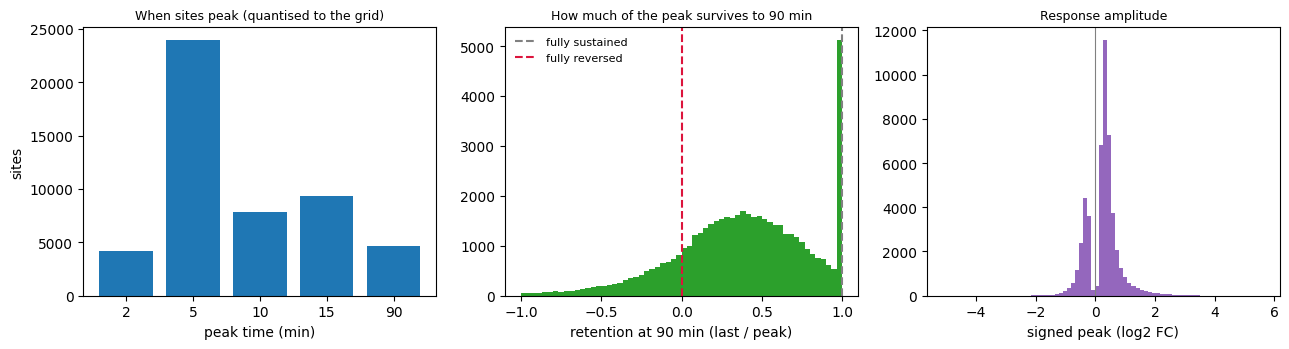

Median retention at 90 min: 0.40


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6),)

_pk = descriptors["peak_time"].dropna()
_counts = _pk.value_counts().sort_index()
axes[0].bar(range(len(_counts)), _counts.to_numpy(), color="tab:blue",)
axes[0].set_xticks(range(len(_counts)),)
axes[0].set_xticklabels([f"{t:g}" for t in _counts.index],)
axes[0].set_xlabel("peak time (min)")
axes[0].set_ylabel("sites")
axes[0].set_title("When sites peak (quantised to the grid)", fontsize=9,)

axes[1].hist(descriptors["retention_90"].clip(-1, 2,).dropna(), bins=60, color="tab:green",)
axes[1].axvline(1.0, color="grey", ls="--", label="fully sustained",)
axes[1].axvline(0.0, color="crimson", ls="--", label="fully reversed",)
axes[1].set_xlabel("retention at 90 min (last / peak)")
axes[1].set_title("How much of the peak survives to 90 min", fontsize=9,)
axes[1].legend(frameon=False, fontsize=8,)

axes[2].hist(descriptors["signed_peak"].dropna(), bins=80, color="tab:purple",)
axes[2].axvline(0, color="grey", lw=0.8,)
axes[2].set_xlabel("signed peak (log2 FC)")
axes[2].set_title("Response amplitude", fontsize=9,)

fig.tight_layout()
plt.show()

print(f"Median retention at 90 min: {descriptors['retention_90'].median():.2f}")

## The shape census — the headline result

Each site is put in one of six classes, using a **noise-aware band** `delta = Z_BAND * SEM`:
an excursion smaller than `delta` is not distinguishable from measurement noise *for that site*.

```
incomplete     : any post-stimulation value missing (never classified on partial data)
non_responsive : max|p| <= delta
biphasic       : responsive AND some p > delta AND some p < -delta
monotonic      : responsive AND not biphasic AND the peak IS the last timepoint
sustained      : responsive AND not biphasic AND peak before the end AND |y_peak - y_last| <= delta
transient      : responsive AND not biphasic AND peak before the end AND |y_peak - y_last| >  delta
```

Only **monotonic** and **sustained** may be fitted with a monotone sigmoid.

### Two things are varied, because both change the answer

**The denominator.** "% fittable" is meaningless without saying *of what*. Two are reported: all
quantified sites, and the statistically **responsive** ones (`n:reps >= 3` and limma omnibus
`FFDR < 0.05` — the same gate `Clustering.ipynb` uses).

**The loading normalisation.** ⚠️ The pipeline applies **none** (`NORMALIZE <- "none"` in
`limma_for_pvalues.rmd`). The raw sample medians span 2.1-fold, and that shift propagates into
every fold change: the median `log2:FC` across *all* sites is around +0.5 at the early EGF
timepoints, against an interquartile range several times smaller. That is the whole distribution
moving, not a tail — and no plausible biology moves every phosphosite in the same direction at
once. Since it inflates apparent responsiveness, the census is computed **both ways**:
as-is, and with the across-site median removed at each timepoint (the fold-change-space stand-in
for median-centring each sample). The real repair belongs upstream in `src/transformations.py`.

### 📖 Explainer — the census: what is being classified, and what "responsive" means

#### The noise band

Everything rests on one per-site quantity:

$$\delta_i = \texttt{Z\_BAND} \times \mathrm{median}_t\!\left(\mathrm{SEM}_{i,t}\right)$$

An excursion smaller than $\delta_i$ is not distinguishable from measurement noise **for that
site** — a well-measured site earns a narrow band and a noisy one a wide band, so the same 0.3 log2
change can count as a response in one site and as noise in another. That is the point: a single
global amplitude cutoff would call the noisy sites responsive and miss the quiet ones. `Z_BAND = 2.5`
means "2.5 standard errors", about the 99% range of pure noise.

#### The six classes, in words

- **`incomplete`** — a post-stimulation value is missing. Never classified on partial data: in
  TMT/DIA proteomics, missingness is not random (low-abundance points go missing preferentially), so
  guessing the shape from what survived would be biased, not merely uncertain.
- **`non_responsive`** — nothing anywhere exceeds $\delta$.
- **`biphasic`** — the profile goes significantly **both** up and down at different timepoints.
- **`monotonic`** — responsive, one direction only, and the peak **is** the last timepoint: still
  going at 90 min.
- **`sustained`** — responsive, one direction, peaks before the end, but the decline from that peak
  is smaller than $\delta$: it plateaus rather than reverses.
- **`transient`** — the same, but the decline **does** exceed $\delta$: up and then detectably back
  down.

Only **`monotonic` + `sustained`** are `sigmoid_legitimate`. A logistic is monotone; fitting one to a
transient site returns a number that looks fine and means nothing (the "What the shape gate is
buying" section measures exactly how many such numbers you would get).

#### What "responsive" means, and the limma column

The headline percentage needs a denominator, and the notebook reports two: all quantified sites, and
the statistically **responsive** ones, defined as `n:reps >= 3` **and** `FFDR < 0.05`.

`FFDR` is produced upstream by **limma** (`limma_for_pvalues.rmd`), a standard package for
differential analysis of omics data. The relevant pieces:

- an **omnibus F-test** asks a single question per site — *does anything change anywhere across this
  time course?* — rather than testing each timepoint separately. "Omnibus" = one test covering all
  the comparisons at once;
- limma applies **empirical-Bayes moderation** to the variances (the same idea as Explainer 2, but
  fitted properly), which is what makes tests on 3–4 replicates usable at all;
- the p-values are then **BH-FDR corrected** across all sites, giving `FFDR`. `FFDR < 0.05` = "among
  the sites I am calling responsive, I expect about 5% to be false".

Using the same gate as `Clustering.ipynb` is deliberate: the two analyses then describe the same set
of sites.

#### Why the census is computed twice

⚠️ The pipeline applies **no loading normalisation** — see CLAUDE.md → Known issues. The raw sample
medians span 2.1-fold, and that offset lands in every fold change: the median `log2:FC` across *all*
sites is about +0.5 at the early EGF timepoints, several times larger than the interquartile range.
No biology moves every phosphosite in the same direction at once, so that is a technical shift, and
it inflates apparent responsiveness.

`center_timepoint_medians` subtracts the across-site median at each timepoint — the fold-change-space
stand-in for median-centring each sample. The census is printed **both ways** so the headline number
is quoted as a bracket rather than as a single figure that depends on an unfixed upstream defect. The
real repair belongs in `src/transformations.py`.


In [53]:
# The two denominators. NOTE: df_raw is already filtered (FFDR + FC amplitude), so
# 'all quantified sites' means all sites that survived that filtering, and the FFDR
# term below is now a no-op — n:reps is the only gate still doing work here.
_nreps = df_raw["n:reps"] >= MIN_REPS
_responsive_mask = (_nreps & (df_raw[FFDR_COL] < MAX_FFDR)).to_numpy()
_all_mask = np.ones(len(df_raw), dtype=bool,)

print(f"all quantified sites : {_all_mask.sum()}")
print(f"n:reps >= {MIN_REPS}          : {int(_nreps.sum())}")
print(f"+ FFDR < {MAX_FFDR}        : {int(_responsive_mask.sum())}   <- headline denominator")
print(f"  (sites limma never tested, FFDR is NaN: {int(df_raw[FFDR_COL].isna().sum())})")

all quantified sites : 50002
n:reps >= 3          : 22973
+ FFDR < 0.05        : 16587   <- headline denominator
  (sites limma never tested, FFDR is NaN: 16283)


In [54]:
# Classify twice: on the data as stored, and after per-timepoint median centring.
# NOTE the SEM used here is the FC branch, deliberately (see the table above): the mean
# branch carries no starve term, so delta would shrink and the census would move for a
# reason that has nothing to do with the data.
values_centered = center_timepoint_medians(values,)

shapes_raw = classify_response_shape(values,
                                     times,
                                     sem_fc,
                                     z     = Z_BAND,
                                     index = df_raw.index,)
shapes_centered = classify_response_shape(values_centered,
                                          times,
                                          sem_fc,
                                          z     = Z_BAND,
                                          index = df_raw.index,)

census_raw = shape_census(shapes_raw["shape_class"],
                          groups = {"all": _all_mask,
                                    "responsive": _responsive_mask,},)
census_centered = shape_census(shapes_centered["shape_class"],
                               groups = {"all": _all_mask,
                                         "responsive": _responsive_mask,},)

print("=== AS STORED (no loading normalisation) ===")
print(census_raw.round(1,).to_string())
print("\n=== AFTER PER-TIMEPOINT MEDIAN CENTRING ===")
print(census_centered.round(1,).to_string())

# The representation everything downstream uses, selected by CENTER_TIMEPOINTS.
_values = values_centered if CENTER_TIMEPOINTS else values     # FC scale, for classification
_shapes = shapes_centered if CENTER_TIMEPOINTS else shapes_raw
print(f"\nDownstream cells use the "
      f"{'median-centred' if CENTER_TIMEPOINTS else 'as-stored'} representation.")

=== AS STORED (no loading normalisation) ===
                       n_all  pct_all  n_responsive  pct_responsive
non_responsive          1095      2.2            17             0.1
monotonic                940      1.9           586             3.5
sustained               5180     10.4          2751            16.6
transient              10796     21.6          8714            52.5
biphasic                4962      9.9          4519            27.2
incomplete             27029     54.1             0             0.0
sigmoid_legitimate      6120     26.6          3337            20.1
needs_transient_model  15758     68.6         13233            79.8

=== AFTER PER-TIMEPOINT MEDIAN CENTRING ===
                       n_all  pct_all  n_responsive  pct_responsive
non_responsive          8419     16.8          5698            34.4
monotonic               2223      4.4          1724            10.4
sustained               6753     13.5          4896            29.5
transient               48

In [55]:
# Median FC per timepoint across all sites — the loading shift, made visible.
print("median log2:FC across ALL sites, per timepoint:")
for _t, _m in zip(times, np.nanmedian(values, axis=0,),):
    print(f"  {_t:>5g} min : {_m:+.3f}")

median log2:FC across ALL sites, per timepoint:
      0 min : +0.000
      2 min : +0.000
      5 min : +0.300
     10 min : +0.195
     15 min : -0.070
     90 min : +0.104


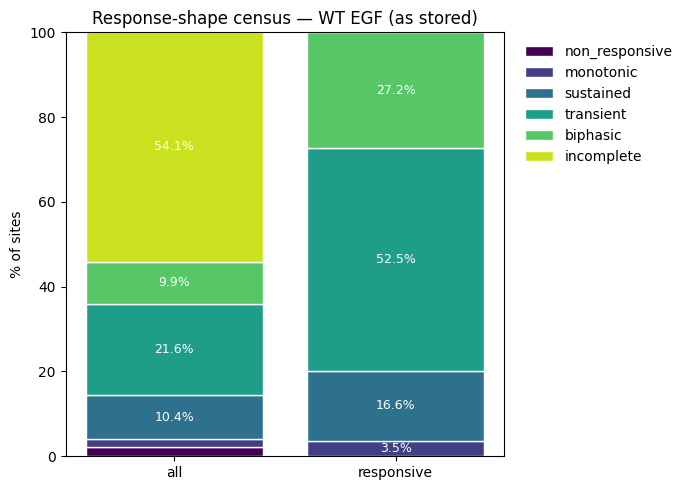

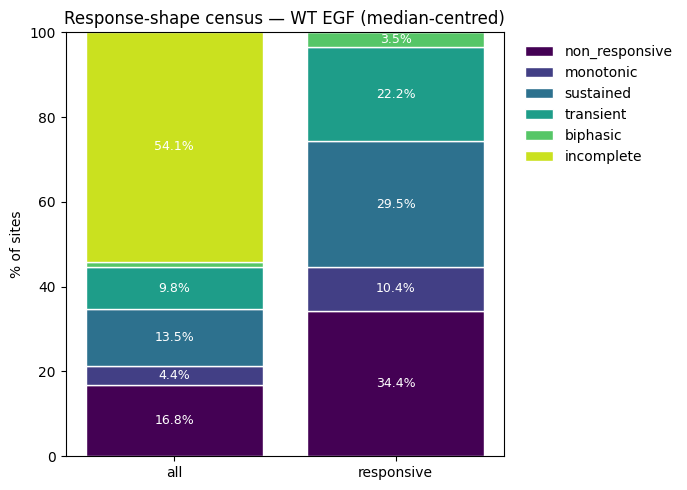

In [56]:
fig, ax = plot_shape_census(census_raw,
                            title = f"Response-shape census — {CELL_LINE} {CONDITION.strip('_')} (as stored)",)
plt.show()

fig, ax = plot_shape_census(census_centered,
                            title = f"Response-shape census — {CELL_LINE} {CONDITION.strip('_')} (median-centred)",)
plt.show()

### How much does the census depend on the noise band?

The boundary between **sustained** and **transient** is "does the decline from the peak exceed
`delta`", so the census moves with `Z_BAND`. Widening the band calls more sites sustained (hence
sigmoid-legitimate); narrowing it calls more sites transient *and* more sites responsive. The
scan below shows the trade explicitly, so the headline percentage is quoted with its sensitivity
rather than as a single hard number.

Note also that `per_site_sem` **propagates the starve reference** — a fold change is a difference
of two means, so its variance is the sum of both — which makes `delta` about √2 wider than a band
built from the timepoint SD alone. That is the more correct error model for fold-change data, and
it is deliberately more permissive: it lets more sites through the shape gate, and leaves the
goodness-of-fit gate to catch the ones that do not actually fit.

### 📖 Explainer — what a sensitivity scan is, and why two of them run here

A **sensitivity analysis** re-runs the analysis across a range of values for a parameter you had to
choose, and reports how much the answer moves. It is not a search for the best value: the point is
to distinguish a conclusion that holds across reasonable choices from one that exists only at the
setting you happened to pick.

Two parameters are scanned because both reach the headline percentage:

- **`Z_BAND`** directly. It sets the noise band, and the `sustained` ↔ `transient` boundary is "is
  the decline bigger than $\delta$" — so a wider band converts transient sites into sustained ones
  (raising "% sigmoid-legitimate") while also converting weak responders into non-responsive ones.
  The two effects push in opposite directions, which is why the trade has to be shown rather than
  argued.
- **`PRIOR_DF`** indirectly, one level down: it changes each site's SEM, which changes $\delta$,
  which changes the census. Invisible unless swept — hence the next scan.

The honest way to report the result is "X% of responsive sites are sigmoid-legitimate, ranging from
Y to Z as the noise band is varied from 1.5 to 4 SEM", not a single number.


In [57]:
_rows = {}
for _z in [1.5, 2.0, 2.5, 3.0, 4.0]:
    _c = classify_response_shape(_values,
                                 times,
                                 sem_fc,
                                 z     = _z,
                                 index = df_raw.index,)
    _t = shape_census(_c["shape_class"],
                      groups = {"responsive": _responsive_mask},)
    _rows[_z] = {"% non-responsive": _t.loc["non_responsive", "pct_responsive"],
                 "% sustained": _t.loc["sustained", "pct_responsive"],
                 "% transient": _t.loc["transient", "pct_responsive"],
                 "% sigmoid-legitimate": _t.loc["sigmoid_legitimate", "pct_responsive"],}

_scan = pd.DataFrame(_rows,).T
_scan.index.name = "Z_BAND"
print(_scan.round(1,).to_string())

        % non-responsive  % sustained  % transient  % sigmoid-legitimate
Z_BAND                                                                  
1.5                  0.1         16.6         52.5                  20.1
2.0                  2.6         31.8         49.7                  35.6
2.5                 12.9         43.4         35.9                  47.1
3.0                 29.3         44.0         22.0                  47.3
4.0                 60.9         28.8          7.7                  31.2


### How much does `prior_df` move the census?

The same question as the `Z_BAND` scan above, one level down. The noise band is
`delta = Z_BAND * median(SEM)`, and `SEM` depends on how hard each site's variance is shrunk
toward the per-timepoint median. So `prior_df` reaches the headline percentage through a path
that is invisible unless it is swept.

The weight the prior takes is `prior_df / (prior_df + d)` with `d = n - 1`. At the inherited
`prior_df = 4` that is **57% at n=4 and 80% at n=3** — the prior outvoting the data, on a
dataset where a third of the counts are n=3.

`prior_df = 0` must be exactly equivalent to switching moderation off; that is asserted first,
because if it is not true the sweep is measuring something else.

### 📖 Explainer — reading the `prior_df` sweep

The mechanics are in Explainer 2. What the table adds is the *consequence*: each row re-derives the
SEMs, re-classifies every site, and then re-fits a random sample of 600 sites, so the columns run
from the low-level quantity all the way to T50.

| column | what it shows |
|---|---|
| `median SEM (FC)` / `median SEM (mean)` | the noise estimate itself, on both scales |
| `median delta` | the resulting per-site noise band |
| `% non-responsive` … `% sigmoid-legitimate` | the census, i.e. which sites are allowed into the fit |
| `n fitted`, `median T50`, `median SE(T50)` | whether any of it reaches the actual answer |

What to look for is a **plateau**: a range of `prior_df` over which the census barely moves. Sitting
on a plateau means the choice is not doing the work. In the measured sweep the census rises by ~3
points from `prior_df = 0` to `2` and is then flat, so `2.0` was adopted as the module default — on
the plateau, but giving the prior 40% of the weight at $n=4$ and 50% at $n=3$ rather than the 57% and
80% that the previously inherited `prior_df = 4` gave it.

The `assert` on the first line is load-bearing: if `prior_df = 0` did not exactly reproduce
`moderate = False`, the sweep would be measuring some other difference as well.


In [58]:
# prior_df = 0 must reproduce moderate=False exactly.
_a = per_site_sem(df_raw, times, CELL_LINE, CONDITION, DATA_TYPE,
                  target = "FC", moderate = True, prior_df = 0.0, min_n = MIN_N,)
_b = per_site_sem(df_raw, times, CELL_LINE, CONDITION, DATA_TYPE,
                  target = "FC", moderate = False, min_n = MIN_N,)
assert np.allclose(_a, _b, equal_nan = True,)
print("assert prior_df = 0 == moderate=False : OK\n")

_rng_sw = np.random.default_rng(0,)
_rows = {}
for _p in [0.0, 1.0, 2.0, 4.0, 8.0]:
    _sfc = per_site_sem(df_raw, times, CELL_LINE, CONDITION, DATA_TYPE,
                        target = "FC", prior_df = _p, min_n = MIN_N,)
    _sfit = per_site_sem(df_raw, times, CELL_LINE, CONDITION, FIT_DATA_TYPE,
                         target = "mean", prior_df = _p, min_n = MIN_N,)
    _c = classify_response_shape(_values, times, _sfc, z = Z_BAND, index = df_raw.index,)
    _t = shape_census(_c["shape_class"], groups = {"responsive": _responsive_mask},)

    # The census gates which sites are fitted; a fit on a sample says what that does to T50.
    _m = _c["sigmoid_legitimate"].to_numpy() & _responsive_mask
    _pick = _rng_sw.choice(np.where(_m)[0], size = min(600, int(_m.sum()),), replace = False,)
    _sub = np.zeros(len(df_raw), dtype = bool,)
    _sub[_pick] = True
    _f = fit_sigmoid_dataset(values_mean, times, _sfit,
                             mask          = _sub,
                             fixed_k       = FIXED_K,
                             free_baseline = FREE_BASELINE,
                             progress      = False,).iloc[_pick]

    _rows[_p] = {"median SEM (FC)": float(np.nanmedian(_sfc[:, times > 0],)),
                 "median SEM (mean)": float(np.nanmedian(_sfit,)),
                 "median delta": float(_c["delta"].median()),
                 "% non-responsive": _t.loc["non_responsive", "pct_responsive"],
                 "% sustained": _t.loc["sustained", "pct_responsive"],
                 "% transient": _t.loc["transient", "pct_responsive"],
                 "% sigmoid-legitimate": _t.loc["sigmoid_legitimate", "pct_responsive"],
                 "n fitted": int(_m.sum()),
                 "median T50": float(_f["t_half_min"].median()),
                 "median SE(T50)": float(_f["se_t_half"].median()),}

_prior_scan = pd.DataFrame(_rows,).T
_prior_scan.index.name = "prior_df"
print(_prior_scan.round(3,).to_string())
print(f"\nPRIOR_DF is set to {PRIOR_DF} in the parameters cell.")

assert prior_df = 0 == moderate=False : OK

          median SEM (FC)  median SEM (mean)  median delta  % non-responsive  % sustained  % transient  % sigmoid-legitimate  n fitted  median T50  median SE(T50)
prior_df                                                                                                                                                          
0.0                 0.114              0.080         0.163             0.350       16.525       50.811                20.034    3323.0       2.762           2.281
1.0                 0.113              0.081         0.164             0.151       16.429       52.065                19.937    3307.0       2.638           2.438
2.0                 0.113              0.082         0.166             0.102       16.585       52.535                20.118    3337.0       2.777           2.395
4.0                 0.113              0.082         0.167             0.054       16.784       52.939                20.311    3369.0       

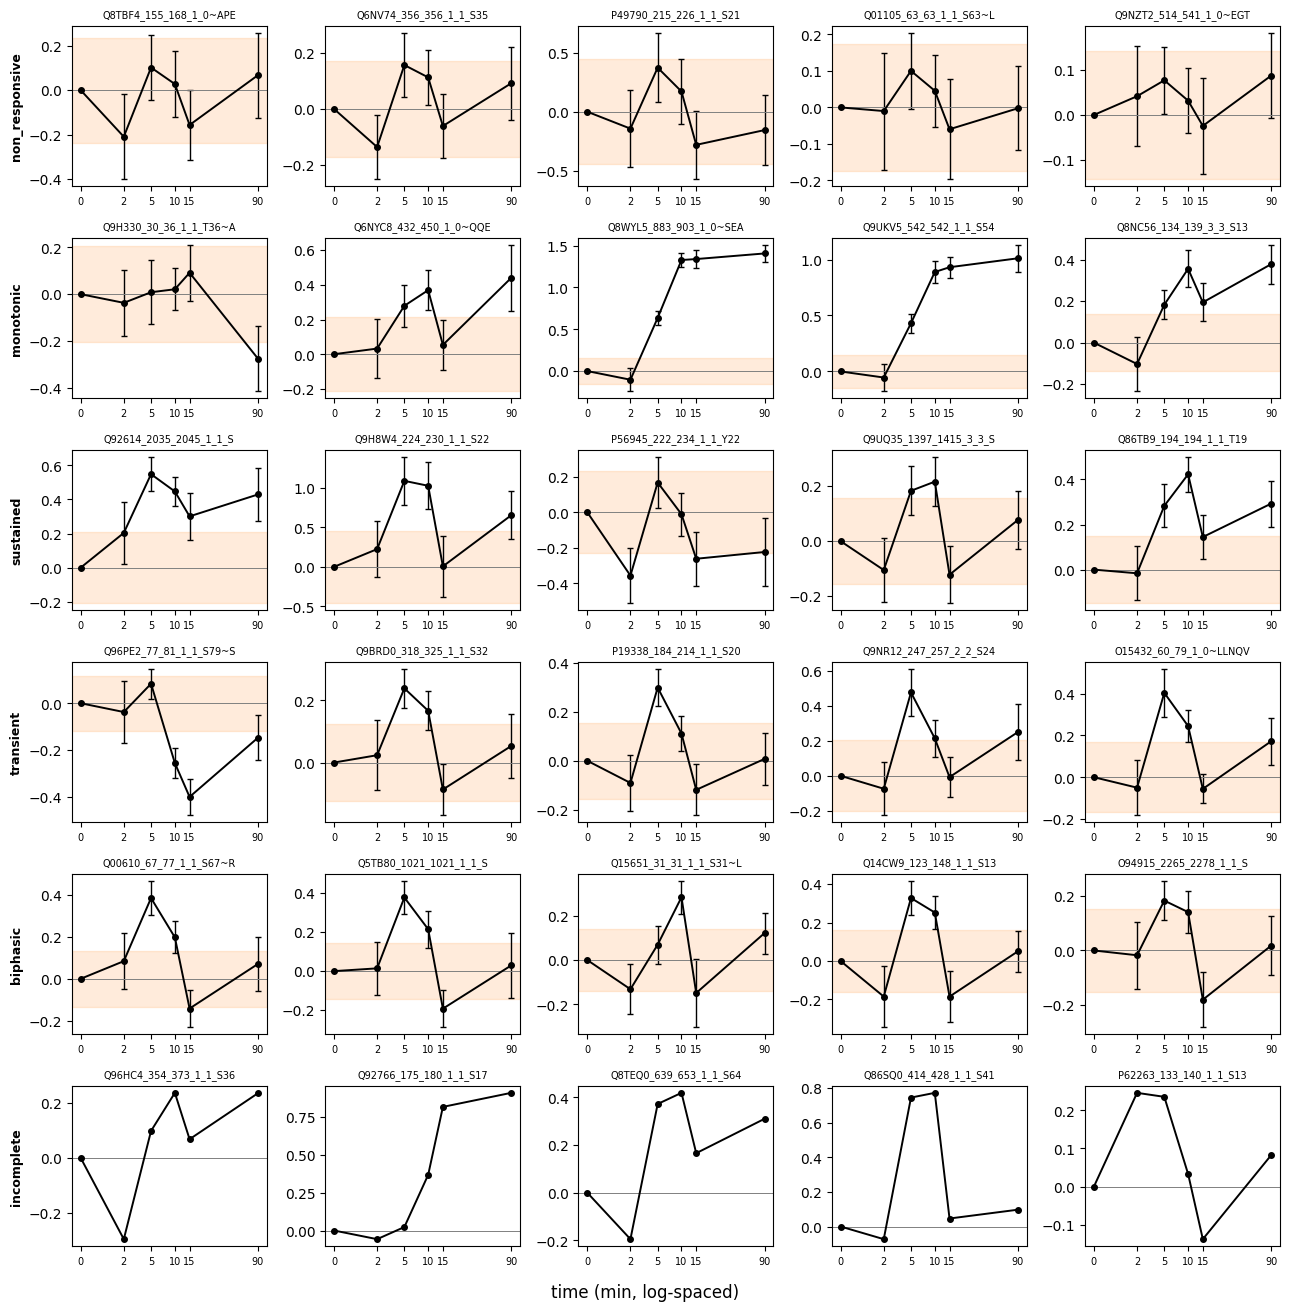

In [59]:
# Eyeball the classification before trusting it to gate the fits.
# Shaded band = the per-site noise band delta the call was made on.
fig, axes = plot_shape_examples(_values,
                                times,
                                _shapes,
                                sem         = sem_fc,
                                n_per_class = 5,
                                labels      = df_raw["site"].tolist(),)
plt.show()

## ⚠️ First: the steepness cannot be estimated from this design

Before fitting, one property of the data has to be established, because it changes the model.

Fitting all three parameters per site drives `k` to whatever upper bound it is given for the
**large majority of sites**, and the resulting standard error on T50 is far larger than the
biological spread — i.e. useless. The cause is not numerical. The first post-stimulation samples
are at 2, 5 and 10 min, and most sites complete their rise *between two of them*, so the data
simply cannot distinguish a steep sigmoid from a step.

`profile_global_k` tests this properly: rather than averaging unstable per-site estimates, it
fits **one shared k** across many sites and profiles the total misfit. If that profile has an
interior minimum, there is a data-driven k. If it falls monotonically to the bound, there is not.

This is the same pathology `council_note_3_temporal_curve_modelling.md` measured for the impulse
model's β (76.5% of fits driven into step-function territory), and the remedy it recommends is the
same: **fit the shared shape parameter globally, then fix it**, leaving each site the two
parameters the data can actually determine — amplitude and timing. Fixing `k` also *buys* a
degree of freedom (3 lack-of-fit df instead of 2), so the goodness-of-fit test gets stronger.

### 📖 Explainer — reading the steepness profile

Concepts: **identifiability**, **profile likelihood**, **parameter bounds** — Explainer 4.

`profile_global_k` walks a grid of candidate $k$ values. At each one it *fixes* $k$ there, refits
600 sites with only their own amplitude and timing free, and sums the weighted misfit ($\chi^2$)
across all of them. The result is a curve of total misfit against $k$.

- **Interior minimum** → the data prefer a particular steepness. Adopt it.
- **Falls monotonically to the edge of the grid** → the data prefer "as steep as allowed", i.e. a
  step function. There is no estimate to adopt; reporting the bound as if it were one would be
  presenting an artefact of the search box as a measurement.

The second outcome is what happens here, and it is a statement about the **design**, not about the
code: with samples at 2, 5 and 10 min, a site that completes its rise between two of them is
compatible with any sufficiently steep curve. No fitter fixes that; only more timepoints would.

Why fit one shared $k$ instead of averaging per-site estimates: the per-site estimates are the
unstable quantity (>90% of them pin at the bound), so their average is an average of artefacts. The
profile never asks any single site to determine $k$ — it asks all of them together.

**Fixing `k` is not a loss.** It removes a parameter the data cannot inform, which buys a
lack-of-fit degree of freedom (3 instead of 2, so the goodness-of-fit test becomes more sensitive)
and removes $k$'s uncertainty from SE(T50). The next section then checks that the choice does not
determine the conclusions.


In [60]:
k_profile = profile_global_k(values_mean,
                             times,
                             sem_fit,
                             mask     = _shapes["sigmoid_legitimate"].to_numpy() & _responsive_mask,
                             n_sample = 600,
                             n_starts = 4,
                             free_baseline = FREE_BASELINE,)
print(k_profile.round(2,).to_string())

_turns_over = k_profile["total_chi2"].idxmin() < k_profile.index.max()
print(f"\nProfile has an interior minimum: {_turns_over}")
if not _turns_over:
    print("  -> no data-driven k exists; the misfit keeps falling towards a step function.")
    print(f"  -> k is therefore fixed by CONVENTION at FIXED_K = {FIXED_K}, justified below.")

           total_chi2  median_rmse  n_lof_ok  n_sites
k                                                    
1.000000      6048.93         0.15     223.0    600.0
1.280955      5732.23         0.15     244.0    600.0
1.640846      5445.34         0.14     274.0    600.0
2.101849      5185.80         0.14     293.0    600.0
2.692374      4933.57         0.14     316.0    600.0
3.448810      4667.47         0.14     336.0    600.0
4.417770      4376.85         0.14     353.0    600.0
5.658964      4070.50         0.13     380.0    600.0
7.248878      3772.75         0.13     421.0    600.0
9.285486      3502.10         0.12     443.0    600.0
11.894288     3292.63         0.12     466.0    600.0
15.236047     3162.75         0.11     482.0    600.0
19.516690     3140.35         0.11     481.0    600.0
25.000000     3160.80         0.11     482.0    600.0

Profile has an interior minimum: True


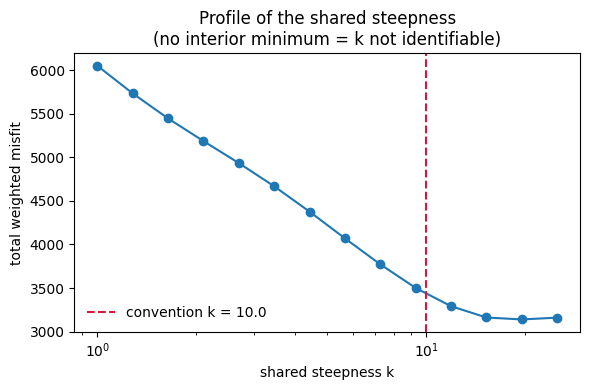

In [61]:
fig, ax = plt.subplots(figsize=(6, 4),)
ax.plot(k_profile.index, k_profile["total_chi2"], marker="o", color="tab:blue",)
ax.axvline(FIXED_K, color="crimson", ls="--", label=f"convention k = {FIXED_K}",)
ax.set_xscale("log",)
ax.set_xlabel("shared steepness k")
ax.set_ylabel("total weighted misfit")
ax.set_title("Profile of the shared steepness\n(no interior minimum = k not identifiable)")
ax.legend(frameon=False,)
fig.tight_layout()
plt.show()

### Is fixing k safe?

A convention is only acceptable if the conclusions survive a different choice. This refits the
same sites at several `k` and reports both the marginal distributions and — the number that
actually matters — the **per-site rank correlation** of T50 between conventions.

If the ordering of sites by T50 is preserved, then every comparative claim (these substrates are
earlier than those; this set is delayed in the mutant) is unaffected by the choice, even though
the absolute T50 carries it.

### 📖 Explainer — why the rank correlation is the number that matters here

Since $k$ is fixed by convention, the obligation is to show that the convention does not drive the
results. `t50_sensitivity_to_k` refits the same sites at several values of $k$ and reports two
things:

- **marginal distributions** (`k_summary`) — how the median T50, its SE and the fit quality shift.
  Expect the absolute T50 to move: a steeper curve reaches half of its plateau sooner;
- **per-site Spearman correlations between conventions** (`k_rank_corr`) — whether the *ordering* of
  sites by T50 is preserved.

Spearman = correlation of ranks (Explainer 4). If it is near 1, then site A responding before site B
is a fact about the data rather than about the value of $k$, and every comparative claim survives —
"substrates of kinase X are earlier than those of kinase Y", "this set is delayed in the mutant".
Only claims about an absolute number ("T50 = 7.3 min") carry the convention with them, and those are
not claims this project makes anyway (Explainer 4, *censoring*, and the per-site SE of ~2.5 min
against a biological IQR of ~3.1 min recorded in `clustering_method_decision.md`).


In [62]:
k_summary, k_rank_corr = t50_sensitivity_to_k(values_mean,
                                              times,
                                              sem_fit,
                                              mask     = _shapes["sigmoid_legitimate"].to_numpy() & _responsive_mask,
                                              n_sample = 800,
                                              n_starts = 4,
                                              free_baseline = FREE_BASELINE,)
print(k_summary.round(3,).to_string())
print("\nSpearman correlation of per-site T50 between k conventions:")
print(k_rank_corr.round(3,).to_string())

         T50_median  T50_q25  T50_q75  median_se_T50  median_rmse  pct_lof_ok  median_plateau
fixed_k                                                                                      
5.0           2.446    1.418    4.606          3.579        0.134      64.375           0.270
10.0          2.855    2.278    4.462          2.342        0.121      79.125           0.268
15.0          2.978    2.498    4.571          1.991        0.114      83.000           0.267
25.0          3.059    2.466    4.673          1.482        0.111      82.625           0.266

Spearman correlation of per-site T50 between k conventions:
       5.0    10.0   15.0   25.0
5.0   1.000  0.964  0.944  0.849
10.0  0.964  1.000  0.966  0.862
15.0  0.944  0.966  1.000  0.904
25.0  0.849  0.862  0.904  1.000


## Fitting the sigmoid

Fitted only on the `sigmoid_legitimate` sites (monotonic + sustained) that also pass the
responsiveness filter, on the **`log2:mean`** matrix with a **free baseline**, and with `k` held
at `FIXED_K` so that only baseline, amplitude and timing are estimated. Weighted least squares
with weights `1/SEM`, 10 optimiser restarts per site (one seeded from the descriptors and the
observed starve level, the rest random inside the parameter box).

Note the scale change: the shape gate was decided on the fold-change matrix, the fit runs on the
mean matrix. Same rows, same minute axis — `build_profile_matrix` preserves row order for both —
but the profiles now sit around 18 log2 units instead of around 0, and the starve point is a
measurement the fit has to account for rather than a constraint it satisfies for free.

Four gates decide whether a T50 may be reported:

| gate | why |
|---|---|
| `rmse_below_noise` | the fit tracks the data to within measurement error |
| `lof_ok` | the lack-of-fit test does not reject the sigmoid shape (**3 df**: 6 points, 3 free parameters `y0, A, x50`) |
| `responsive` | the sigmoid beats the flat null after BH-FDR |
| `identifiable` | SE of the inflection is finite and small — not sitting on a flat likelihood ridge |

`t50_censored` is reported **separately**: a censored fit is a successful fit whose T50 must be
written as `< 2 min`, not a failed one.

### ⚠️ The null gained a parameter, and it is not cosmetic

On the fold-change scale "no response" is the **exact curve `y = 0`** with zero free parameters —
the fold change is anchored at starve, so a flat site is fully specified. On the mean scale it is
a **fitted constant `y = y0`**, one free parameter, and `chi2_null` is the weighted residual sum
about the weighted mean level over *all* timepoints, starve included.

Get this wrong and every `p_vs_flat` is wrong in the same direction: a site sitting flat at 18.4
log2 units, measured against a `y = 0` null, looks overwhelmingly responsive. The sanity-check
cell at the top of the notebook pushes 400 pure-noise sites through both nulls to demonstrate
exactly that, which is why `compare_to_flat` takes `free_baseline` rather than inferring it. The
df of the difference test follows: `n_free_sigmoid - n_free_null`.

The responsiveness test is a **chi-square difference test**, not an F-test, and the distinction
is not cosmetic. The measurement errors are known (the per-site SEMs), so the noise scale does not
need estimating from the residuals — and an F-test that re-estimates it from the 2–3 residual df
this design leaves has essentially no power. On this data the sigmoid cuts the median chi-square
by roughly a factor of four, an overwhelming improvement, yet an F-test returns a median *p*
around 0.37 and rejects **every** site. The chi-square difference test on the identical numbers
passes the large majority.

### Expect fewer sites to pass `lof_ok` than on the fold-change scale

Not a regression. The FC-scale SEM carries the starve variance a second time in every timepoint
(median 0.113 against 0.082 on the mean scale), and inflated errors make any model look adequate.
Measured on 1500 sites here, the lack-of-fit test goes from ~45% not-rejected to ~21% while the
median RMSE actually *improves* slightly. The old pass rate was flattering the fit.

### 📖 Explainer — what the fitting cell does, and every column it produces

#### The call

`fit_sigmoid_dataset` loops over the gated sites and, for each, runs the procedure from Explainer 0:
weighted least squares (weights `1/SEM`), $k$ held at `FIXED_K`, `N_STARTS = 10` optimiser restarts.

**Why restarts.** The optimiser walks downhill from wherever it starts, so it can settle in a **local
minimum** — a dip in the cost surface that is not the deepest one. Ten different starting points are
tried and the lowest-cost result is kept. The first start is not random: it is seeded from the site's
own descriptors (observed peak, observed starve level), which is usually already close. The column
`n_starts_at_optimum` records how many of the ten reached the same solution — a quick per-site read
on whether the optimum is well defined.

`compare_to_flat` then adds the responsiveness test (Explainer 3), and `fit_quality_gates` converts
the raw statistics into booleans.

#### The columns of `fits`

| column | meaning |
|---|---|
| `y0` | fitted baseline (0 under the hard anchor) |
| `A` | amplitude parameter |
| `k` | steepness — equal to `FIXED_K` for every site here, not an estimate |
| `x50` | inflection point on the $\log_{10}(t+1)$ axis |
| `se_*` | asymptotic standard error of the corresponding parameter |
| `plateau` | final level relative to baseline, in log2 fold-change units — **the amplitude to report** |
| `t50_min` | inflection *time*, $10^{x_{50}} - 1$. Not the headline number |
| **`t_half_min`** | **T50: time to reach half the plateau. This is the headline number** |
| `se_t_half` | its standard error, by the delta method |
| `rss`, `rmse` | unweighted misfit; `rmse` is in log2 units |
| `chi2` | SEM-weighted misfit |
| `df_lof`, `p_lof` | lack-of-fit df and p-value (**large p = good**) |
| `n_points` | observations used: 5 hard-anchored, 6 soft-anchored |
| `converged`, `n_starts_at_optimum` | optimiser diagnostics |
| `chi2_null`, `y0_null`, `delta_chi2`, `df_vs_flat` | the flat-model comparison |
| `p_vs_flat`, `fdr_vs_flat` | its p-value and BH-adjusted value (**small = good**) |
| `bic_sigmoid`, `bic_flat` | BIC of each model; lower wins |

#### The gates

`fit_ok` is the AND of five conditions, each catching a different failure:

| gate | fails when | the failure it prevents |
|---|---|---|
| `converged` | the optimiser returned nothing usable | — |
| `rmse_below_noise` | `rmse >= SIGMA` | the curve does not actually track the points |
| `lof_ok` | `p_lof <= 0.05` | the misfit is bigger than the noise can explain: wrong shape |
| `responsive` | `fdr_vs_flat >= 0.05` | a flat line would have done as well: there is no response to time |
| `identifiable` | `se_x50` missing, `>= 1.0`, or `k` pinned at its bound | the answer sits on a flat ridge — the reported timing is arbitrary |

`t50_censored` is deliberately **not** part of `fit_ok`: a censored fit is a good fit whose answer
must be written as `< 2 min` or `> 60 min` (Explainer 4).

The summary cell then prints the funnel — all sites → responsive → sigmoid-legitimate → passing every
gate — with the per-gate failure counts, which is the honest way to present how few sites survive and
why.


In [63]:
fit_mask = _shapes["sigmoid_legitimate"].to_numpy() & _responsive_mask
print(f"Sites entering the fit: {int(fit_mask.sum())}")

# ⚠️ The shape gate was decided on the FOLD-CHANGE matrix; the fit runs on the MEAN matrix. Same
# rows, same minute axis, different scale — `build_profile_matrix` preserves row order for both.
fits = fit_sigmoid_dataset(values_mean,
                           times,
                           sem_fit,
                           mask          = fit_mask,
                           log_time      = LOG_TIME,
                           n_starts      = N_STARTS,
                           fixed_k       = FIXED_K,
                           free_baseline = FREE_BASELINE,
                           index         = df_raw.index,
                           n_jobs        = N_JOBS,)
# free_baseline must match here too: it selects the null the sigmoid is tested against (a fitted
# constant, one free parameter) and the df of the difference test.
fits = compare_to_flat(fits,
                       values_mean,
                       times,
                       sem_fit,
                       free_baseline = FREE_BASELINE,)
fits = fit_quality_gates(fits,
                         sigma = SIGMA,)

print(fits.loc[fit_mask,
               ["y0", "A", "k", "plateau", "t50_min", "t_half_min", "se_t_half",
                "rmse", "p_lof", "fdr_vs_flat", "fit_ok", "t50_censored"]].head(8,).round(3,).to_string())

Sites entering the fit: 3337


sigmoid fits: 100%|██████████| 3337/3337 [03:15<00:00, 17.06site/s]


     y0      A     k  plateau  t50_min  t_half_min  se_t_half   rmse  p_lof  fdr_vs_flat  fit_ok  t50_censored
1   0.0  0.496  10.0    0.495    3.795       3.797      2.378  0.153  0.337        0.000    True         False
2   0.0  0.063  10.0    0.062    1.706       1.723      8.191  0.129  0.071        0.494   False          True
8   0.0  0.380  10.0    0.379    2.892       2.897      2.466  0.157  0.259        0.000    True         False
12  0.0  0.139  10.0    0.138    1.964       1.976      5.171  0.120  0.020        0.007   False          True
24  0.0 -0.347  10.0   -0.347   11.135      11.135      7.333  0.201  0.125        0.056   False         False
36  0.0  0.218  10.0    0.216    1.956       1.968      4.472  0.153  0.004        0.000   False          True
53  0.0  0.286  10.0    0.285    3.170       3.174      2.658  0.135  0.079        0.000    True         False
57  0.0  0.223  10.0    0.210    0.895       0.947      4.860  0.130  0.032        0.000   False          True


In [64]:
# ── The headline numbers ────────────────────────────────────────────────────
_n_all        = int(_all_mask.sum())
_n_responsive = int(_responsive_mask.sum())
_n_gated      = int(fit_mask.sum())
_n_ok         = int(fits["fit_ok"].fillna(False,).sum())
_n_censored   = int((fits["fit_ok"].fillna(False,) & fits["t50_censored"].fillna(False,)).sum())

print(f"All quantified sites                       : {_n_all}")
print(f"Responsive (n:reps>={MIN_REPS}, FFDR<{MAX_FFDR})          : {_n_responsive}"
      f"  ({100 * _n_responsive / _n_all:.1f}% of all)")
print(f"...of which sigmoid-legitimate by shape    : {_n_gated}"
      f"  ({100 * _n_gated / _n_responsive:.1f}% of responsive)")
print(f"...of which pass every fit-quality gate    : {_n_ok}"
      f"  ({100 * _n_ok / _n_gated:.1f}% of fitted, {100 * _n_ok / _n_responsive:.1f}% of responsive)")
print(f"   of those, T50 left/right censored       : {_n_censored}"
      f"  ({100 * _n_censored / max(_n_ok, 1):.1f}% — report as an inequality)")
print()
print("Reason for exclusion among the fitted sites:")
for _g in ["converged", "rmse_below_noise", "lof_ok", "responsive", "identifiable"]:
    _fail = int((~fits.loc[fit_mask, _g].fillna(False,).astype(bool)).sum())
    print(f"   failed {_g:<18}: {_fail}")

All quantified sites                       : 50002
Responsive (n:reps>=3, FFDR<0.05)          : 16587  (33.2% of all)
...of which sigmoid-legitimate by shape    : 3337  (20.1% of responsive)
...of which pass every fit-quality gate    : 2190  (65.6% of fitted, 13.2% of responsive)
   of those, T50 left/right censored       : 237  (10.8% — report as an inequality)

Reason for exclusion among the fitted sites:
   failed converged         : 0
   failed rmse_below_noise  : 231
   failed lof_ok            : 765
   failed responsive        : 270
   failed identifiable      : 185


## What the shape gate is buying

The argument for classifying before fitting is that the optimiser does not refuse a transient
site — it returns a number. This fits sigmoids to a sample of the sites the gate **excludes** and
counts how many would have passed the goodness-of-fit gate anyway.

Those sites are the ones that would have entered a T50 table with a plausible, wrong value if the
shape gate were dropped.

### 📖 Explainer — the corruption check: measuring what the shape gate prevents

A gate is only worth having if something bad gets through when it is removed. This cell takes a
sample of the sites the census **excluded** (transient and biphasic), fits sigmoids to them anyway,
and counts how many would have passed the goodness-of-fit gates.

Those are the false positives the gate is buying: sites that would have entered a T50 table with a
plausible number attached to a curve of the wrong shape. A monotone sigmoid fitted to a rise-and-fall
profile typically either follows the rising limb and treats the entire decline as residual, or
compromises through the middle — pushing T50 late and shrinking the amplitude — or, for a site that
returns fully to baseline, fits a nearly flat curve and reclassifies the site as non-responsive. All
three failures are silent.

The number this cell prints is therefore the quantitative justification for classifying before
fitting, rather than trusting the lack-of-fit test to notice afterwards.


In [65]:
corruption = corruption_check(values_mean,
                              times,
                              sem_fit,
                              _shapes,
                              sigma     = SIGMA,
                              n_sample  = 400,
                              n_starts  = N_STARTS,
                              fixed_k   = FIXED_K,
                              free_baseline = FREE_BASELINE,)
print(corruption.round(2,).to_string())

           n_tested  n_passing_gof  pct_passing_gof  median_t_half_min
transient     400.0          115.0            28.75               2.35
biphasic      400.0           38.0             9.50              11.34


## T50 results

### 📖 Explainer — how to read the three result figures

**`plot_gof_summary`** — goodness-of-fit diagnostics over the fitted sites: the RMSE distribution
against `SIGMA` (bulk should sit left of the line), the lack-of-fit p-values (under a correct model
these are roughly **uniform** between 0 and 1 — a spike at 0 means systematic misfit), and the
identifiability diagnostics.

**`plot_t50_distribution`** — the biology. Where the fitted half-response times pile up, split by
whether the site passed `fit_ok`. Watch the left edge: the accumulation at 2 min is the censoring
bound (Explainer 4), not a genuine mode.

**T50 vs model-free peak time** — the cross-check between the two summarisation routes. T50 should
land at or *before* the observed peak, because half of the response is reached before all of it is.
Points well **above** the diagonal are fits describing a different event from the one visible in the
data and are worth inspecting individually. The x-axis is jittered (a small random offset added) only
so that thousands of points quantised onto five grid values do not overplot into five vertical
lines; the y-axis is `symlog`, i.e. logarithmic away from zero but linear near it, so that both the
2-minute pile and the 90-minute tail are visible on one axis.

**`plot_fit_examples`** — twelve individual sites: the four best-determined (smallest `se_t_half`),
four median ones and the four worst that still passed. Looking at the extremes of the distribution
is the cheapest way to catch a systematic problem that summary statistics average away.


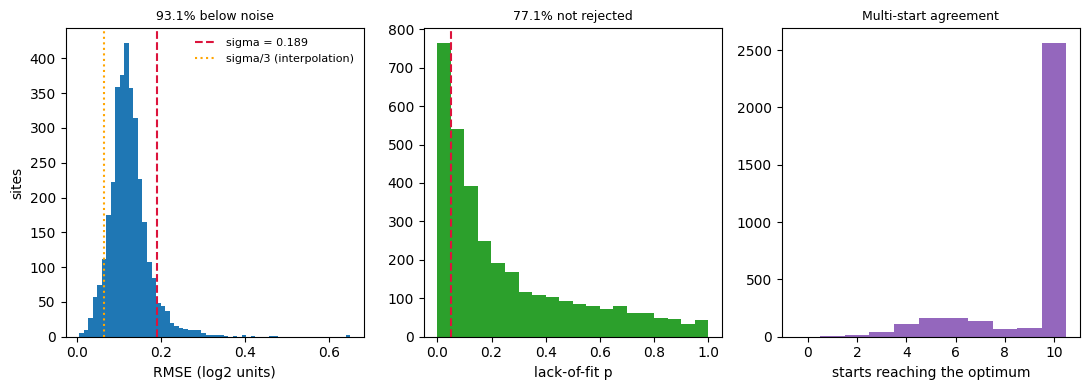

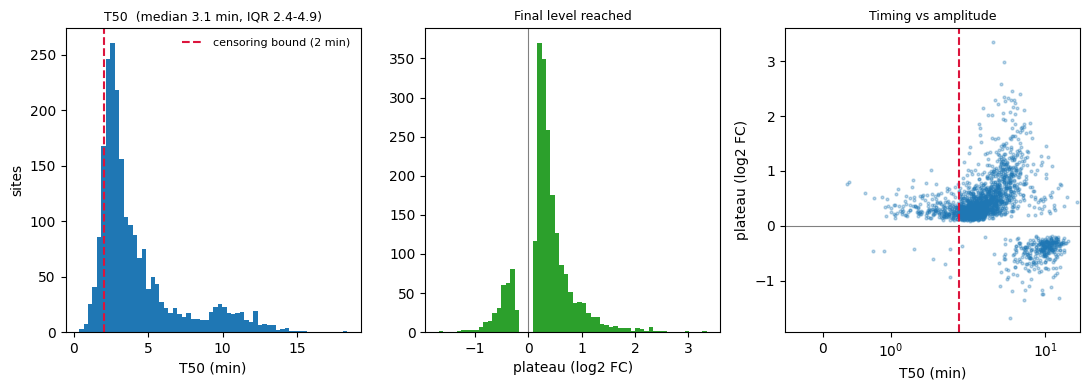

In [66]:
fig, axes = plot_gof_summary(fits.loc[fit_mask],
                             sigma = SIGMA,)
plt.show()

fig, axes = plot_t50_distribution(fits,
                                  gate_col = "fit_ok",)
plt.show()

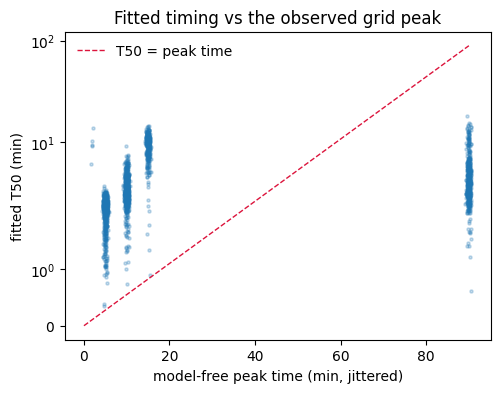

In [67]:
# T50 against the model-free peak time: a fit whose T50 lands after its own observed peak
# is not describing the same event the data shows.
_ok = fits["fit_ok"].fillna(False,).to_numpy()
fig, ax = plt.subplots(figsize=(5.5, 4),)
ax.scatter(descriptors.loc[_ok, "peak_time"] + np.random.default_rng(0,).normal(0, 0.25, _ok.sum(),),
           fits.loc[_ok, "t_half_min"],
           s     = 5,
           alpha = 0.25,)
ax.plot([0, 90], [0, 90], color="crimson", ls="--", lw=1, label="T50 = peak time",)
ax.set_yscale("symlog",)
ax.set_xlabel("model-free peak time (min, jittered)")
ax.set_ylabel("fitted T50 (min)")
ax.set_title("Fitted timing vs the observed grid peak")
ax.legend(frameon=False,)
plt.show()

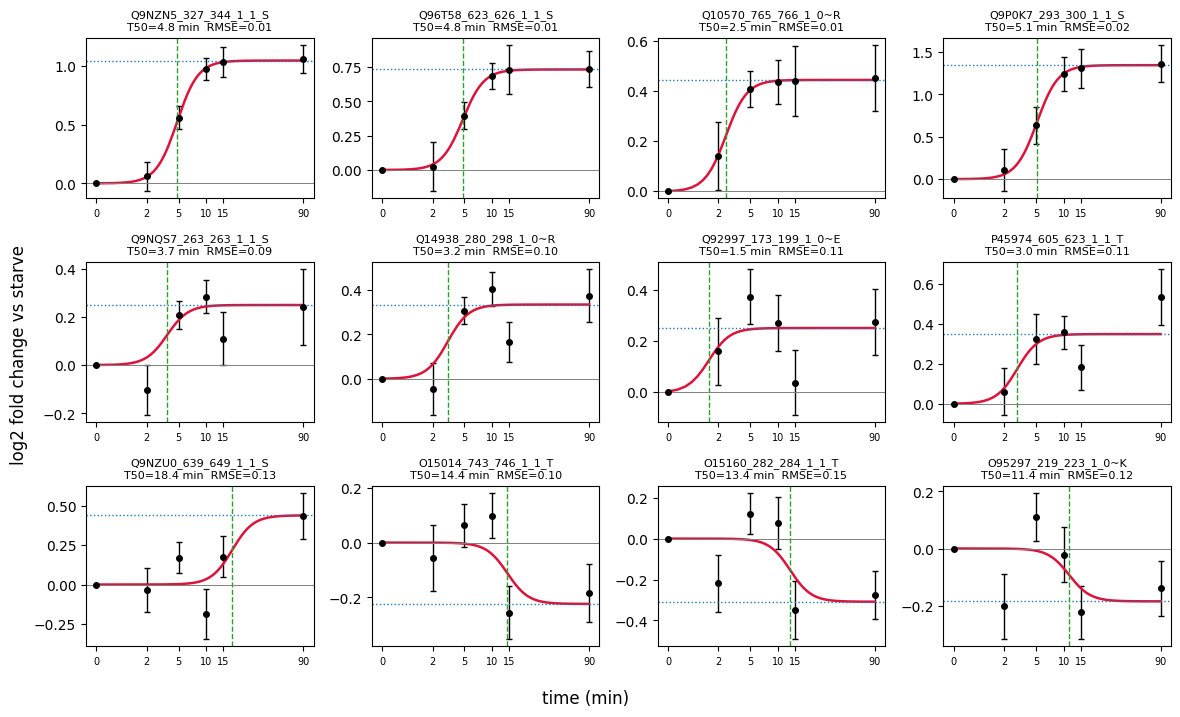

In [68]:
# Exemplar fits: the best-determined, the median, and the worst that still passed.
_ok_pos = np.where(_ok)[0]
_by_se  = _ok_pos[np.argsort(fits["se_t_half"].to_numpy()[_ok_pos],)]
_show   = np.r_[_by_se[:4], _by_se[len(_by_se) // 2: len(_by_se) // 2 + 4], _by_se[-4:]]

fig, axes = plot_fit_examples(values_mean,
                              times,
                              fits,
                              _show,
                              sem      = sem_fit,
                              labels   = df_raw["site"].tolist(),
                              log_time = LOG_TIME,)
plt.show()

## Does the soft anchor actually change anything?

This is the validation that justifies fitting on `log2:mean` at all, and it is a **negative**
result by design: the two parameterisations must agree.

The same shape-gated sites are fitted twice — hard-anchored on `log2:FC`, soft-anchored on
`log2:mean` — and compared site by site. What to look for:

- **`t_half_min` should track closely**, since the anchor is a statement about the baseline, not
  about timing.
- **Disagreement should concentrate in sites with a large `SEM(starve)`.** Those are exactly the
  sites whose baseline the hard anchor was asserting it knew exactly. That single scatter plot is
  the whole argument for the change.
- **Large disagreement on *well-measured* sites would mean something is wired wrong**, not that
  the new model is better.

⚠️ Read the rank correlation with the censoring in mind. T50 is heavily piled against the 2-min
left-censoring bound (the first post-stimulation sample), and ranks inside that pile are noise,
not information. The correlation is therefore reported both overall and on the sites where T50 is
genuinely resolved.

### 📖 Explainer — what this validation can and cannot show

The logic here is worth being explicit about, because it is the opposite of a normal result section:
**agreement is the successful outcome.**

The claim being made for the soft anchor is not "it gives better answers". It is "it makes an
assumption that is actually true (independent errors) instead of one that is only approximately true,
at no cost in degrees of freedom". If a claim of that kind is honest, then the answers must barely
move — a large shift would mean the old fits were being dragged around by the baseline assumption,
which is a much stronger and much less likely claim.

So there are three possible outcomes and only one of them is good:

| observed | interpretation |
|---|---|
| T50 tracks closely; disagreement concentrated in sites with large `SEM(starve)` | ✅ expected. The two agree wherever the baseline was well measured, and differ only where the hard anchor was asserting a baseline it did not know |
| large disagreement on **well-measured** sites | ❌ something is wired wrong — a mismatched scale, mask or SEM branch — not a better model |
| perfect agreement everywhere including noisy baselines | ⚠️ suspicious: the free baseline is not doing anything, so check it is actually free |

The right-hand panel of the figure is the whole argument in one plot: |ΔT50| against the SEM of the
starve mean, with a binned median through it. An upward trend is the signature being looked for.

⚠️ **Read the Spearman correlations with the censoring in mind.** T50 piles up against the 2-minute
bound, and ranks inside that pile are noise. Hence the correlation is reported overall *and* on
resolved sites (T50 > 3 min) — a lower overall value reflects censoring, not disagreement.

**Also expect the lack-of-fit test to reject more on the mean scale, and do not read that as a
regression.** The FC-scale SEMs are inflated by the starve variance being counted twice (Explainer 2),
and inflated errors flatter *any* model — $\chi^2$ divides by them. The printout at the end shows the
median RMSE simultaneously *improving* while the chi-square rises: the fits got slightly better and
the test got more honest.


In [69]:
# Fit the same sites both ways. A sample, because this is a diagnostic, not a deliverable.
_n_val = 1500
_val_pos = np.random.default_rng(0,).choice(np.where(fit_mask)[0],
                                            size    = min(_n_val, int(fit_mask.sum()),),
                                            replace = False,)
_val_mask = np.zeros(len(df_raw), dtype = bool,)
_val_mask[_val_pos] = True

_hard_fits = fit_sigmoid_dataset(_values,                 # log2:FC
                                 times,
                                 sem_fc,
                                 mask          = _val_mask,
                                 log_time      = LOG_TIME,
                                 n_starts      = N_STARTS,
                                 fixed_k       = FIXED_K,
                                 free_baseline = False,
                                 progress      = False,).iloc[_val_pos]
_soft_fits = fits.iloc[_val_pos]                          # log2:mean, already fitted above

_H = _hard_fits["t_half_min"].to_numpy(dtype = float,)
_S = _soft_fits["t_half_min"].to_numpy(dtype = float,)
_ok_val = np.isfinite(_H) & np.isfinite(_S)

print(f"=== hard anchor (log2:FC) vs soft anchor (log2:mean) — {int(_ok_val.sum())} sites ===\n")
for _c in ["A", "x50", "t_half_min", "plateau", "rmse", "se_t_half",]:
    _h = _hard_fits[_c].to_numpy(dtype = float,)
    _s = _soft_fits[_c].to_numpy(dtype = float,)
    _m = np.isfinite(_h) & np.isfinite(_s)
    print(f"  {_c:<12} spearman {spearmanr(_h[_m], _s[_m],).statistic:6.3f}    "
          f"median  hard {np.median(_h[_m]):8.4f}   soft {np.median(_s[_m]):8.4f}")

_d = np.abs(_H - _S)[_ok_val]
_se = _hard_fits["se_t_half"].to_numpy(dtype = float,)[_ok_val]
print(f"\n  median |dT50|            {np.median(_d):.3f} min")
print(f"  median per-site SE(T50)  {np.nanmedian(_se):.3f} min"
      f"   -> the disagreement is {100 * np.median(_d) / np.nanmedian(_se):.1f}% of the SE")

# Censoring, not disagreement: ranks inside the pile at the 2 min bound carry no information.
for _lo, _hi, _lab in [(0.0, 2.0, "T50 < 2 min (censored)",),
                       (2.0, 60.0, "T50 in [2, 60] min",),
                       (3.0, 60.0, "T50 > 3 min (resolved)",),]:
    _m = _ok_val & (_H >= _lo) & (_H <= _hi)
    if _m.sum() > 20:
        print(f"  spearman(T50) {_lab:<26} {spearmanr(_H[_m], _S[_m],).statistic:6.3f}   (n = {int(_m.sum())})")

=== hard anchor (log2:FC) vs soft anchor (log2:mean) — 1500 sites ===

  A            spearman  1.000    median  hard   0.2658   soft   0.2658
  x50          spearman  1.000    median  hard   0.5812   soft   0.5812
  t_half_min   spearman  1.000    median  hard   2.8173   soft   2.8173
  plateau      spearman  1.000    median  hard   0.2588   soft   0.2588
  rmse         spearman  1.000    median  hard   0.1183   soft   0.1183
  se_t_half    spearman  1.000    median  hard   2.4265   soft   2.4265

  median |dT50|            0.000 min
  median per-site SE(T50)  2.427 min   -> the disagreement is 0.0% of the SE
  spearman(T50) T50 < 2 min (censored)      1.000   (n = 254)
  spearman(T50) T50 in [2, 60] min          1.000   (n = 1246)
  spearman(T50) T50 > 3 min (resolved)      1.000   (n = 666)


/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_13554/819007608.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _rho = spearmanr(_d[_m_plot], _sem_starve[_m_plot],)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


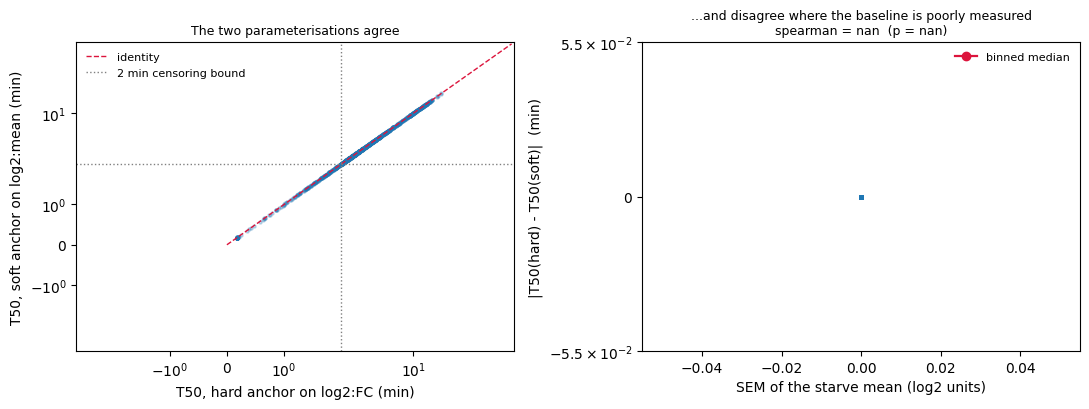

median |dT50|, well-measured half of sites : 0.000 min
median |dT50|, noisier half of sites       : nan min

That is the whole argument: the fits agree far inside their own uncertainty, and what
disagreement there is sits where the hard anchor was asserting a baseline it did not know.

lack-of-fit not rejected:  hard 77.4%   soft 77.4%
median chi-square:         hard 5.37        soft 5.37
median RMSE:               hard 0.1183      soft 0.1183


In [70]:
# THE plot: does the disagreement live where the starve measurement is poor?
_sem_starve = sem_fit[_val_pos, 0][_ok_val]
_m_plot = np.isfinite(_sem_starve) & np.isfinite(_d)
_rho = spearmanr(_d[_m_plot], _sem_starve[_m_plot],)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2),)

axes[0].scatter(_H[_ok_val], _S[_ok_val], s=5, alpha=0.25,)
axes[0].plot([0, 90], [0, 90], color="crimson", ls="--", lw=1, label="identity",)
axes[0].axvline(2.0, color="grey", ls=":", lw=1, label="2 min censoring bound",)
axes[0].axhline(2.0, color="grey", ls=":", lw=1,)
axes[0].set_xscale("symlog",)
axes[0].set_yscale("symlog",)
axes[0].set_xlabel("T50, hard anchor on log2:FC (min)")
axes[0].set_ylabel("T50, soft anchor on log2:mean (min)")
axes[0].set_title("The two parameterisations agree", fontsize=9,)
axes[0].legend(frameon=False, fontsize=8,)

axes[1].scatter(_sem_starve[_m_plot], _d[_m_plot], s=5, alpha=0.25,)
_bins = np.quantile(_sem_starve[_m_plot], np.linspace(0, 1, 9,),)
_mid = 0.5 * (_bins[:-1] + _bins[1:])
_med = [np.median(_d[_m_plot][(_sem_starve[_m_plot] >= a) & (_sem_starve[_m_plot] < b)])
        for a, b in zip(_bins[:-1], _bins[1:],)]
axes[1].plot(_mid, _med, color="crimson", marker="o", lw=1.6, label="binned median",)
axes[1].set_yscale("symlog", linthresh=0.1,)
axes[1].set_xlabel("SEM of the starve mean (log2 units)")
axes[1].set_ylabel("|T50(hard) - T50(soft)|  (min)")
axes[1].set_title(f"...and disagree where the baseline is poorly measured\n"
                  f"spearman = {_rho.statistic:.3f}  (p = {_rho.pvalue:.1e})", fontsize=9,)
axes[1].legend(frameon=False, fontsize=8,)

fig.tight_layout()
plt.show()

_half = np.median(_sem_starve[_m_plot],)
print(f"median |dT50|, well-measured half of sites : "
      f"{np.median(_d[_m_plot][_sem_starve[_m_plot] <= _half]):.3f} min")
print(f"median |dT50|, noisier half of sites       : "
      f"{np.median(_d[_m_plot][_sem_starve[_m_plot] >  _half]):.3f} min")
print("\nThat is the whole argument: the fits agree far inside their own uncertainty, and what")
print("disagreement there is sits where the hard anchor was asserting a baseline it did not know.")

# Expect the lack-of-fit test to bite harder on the mean scale. The FC SEM double-counts the
# starve variance, and inflated errors make any model look adequate.
print(f"\nlack-of-fit not rejected:  hard {100 * (_hard_fits['p_lof'] > 0.05).mean():.1f}%   "
      f"soft {100 * (_soft_fits['p_lof'] > 0.05).mean():.1f}%")
print(f"median chi-square:         hard {_hard_fits['chi2'].median():.2f}        "
      f"soft {_soft_fits['chi2'].median():.2f}")
print(f"median RMSE:               hard {_hard_fits['rmse'].median():.4f}      "
      f"soft {_soft_fits['rmse'].median():.4f}")

## Why log-time, on this data

The timepoints span a factor of 45 but are sampled densely at the short end. **Leverage** `h_ii`
measures how much an observation determines its own fitted value; a bar approaching 1.0 is a
single measurement dictating the whole curve. On this design the 90 min point carries leverage
**0.979** in linear time against **0.659** in `log10(t+1)` — one measurement, with an SEM of
about 0.14, essentially dictating the fit.

`compare_time_axes` then fits the same sites both ways. Expect the RMSEs to be nearly identical:
**log-time is not a better fit, it is a better parameterisation.**

⚠️ **Read the `k_q90_over_q10` column with care in the run below.** The classical argument for
log-time is that the steepness `k` is confounded with timing in linear time (it varies ~30-fold
between a fast and a slow site, so it cannot be compared across sites or clustered) while in
log-time it varies only ~1.5-fold. That comparison **cannot be made here**, because `FIXED_K`
holds `k` constant — so the column reports 1.0 on both axes by construction, not as a result.
Set `FIXED_K = None` and re-run this section if you want that evidence; the leverage panel above
stands on its own either way.


### 📖 Explainer — the leverage panel

Definition in Explainer 4. `plot_leverage` computes $h_{ii}$ for the two candidate time axes and
plots them side by side. It is computed for a **straight-line** model on purpose: leverage is a
property of *where the samples sit*, not of the curve fitted to them, so the standard linear
diagnostic transfers directly and needs no assumptions about the sigmoid.

Read it as: on a raw-minute axis, the 90-minute point is nearly the whole design. Its
$h_{ii} = 0.979$ means the fitted curve is obliged to pass through it almost exactly, so a single
measurement with an SEM of ~0.14 determines the curve. On $\log_{10}(t+1)$ the five points share the
influence far more evenly.

`compare_time_axes` then fits the same sites on both axes. Expect near-identical RMSEs — again, the
argument for log-time is parameterisation, not fit quality.

⚠️ One column in that table cannot be read in this run: `k_q90_over_q10` (the 90th/10th percentile
ratio of fitted $k$) reports 1.0 on both axes **by construction**, because `FIXED_K` holds $k$
constant. The classical argument — that $k$ is confounded with timing in linear time, varying ~30-fold
across sites, but only ~1.5-fold in log-time — would need `FIXED_K = None` to be demonstrated here.
The leverage panel stands on its own regardless.


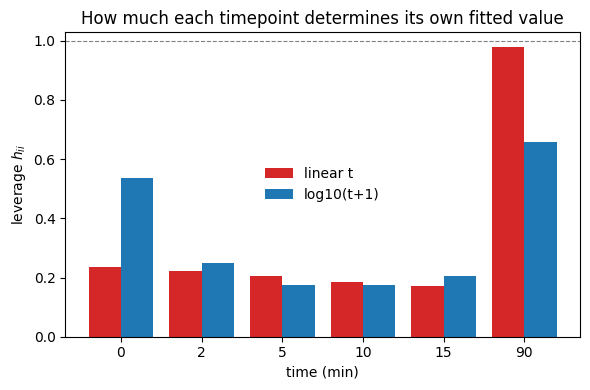

                n  median_rmse  pct_negative_T50  k_q90_over_q10
log10(t+1)  400.0        0.118               0.0             1.0
linear t    400.0        0.123               0.0             1.0


In [71]:
fig, ax = plot_leverage(times,)
plt.show()

axes_comparison = compare_time_axes(values_mean,
                                    times,
                                    sem_fit,
                                    mask      = fit_mask,
                                    n_sample  = 400,
                                    n_starts  = N_STARTS,
                                    fixed_k   = FIXED_K,
                                    free_baseline = FREE_BASELINE,)
print(axes_comparison.round(3,).to_string())

## Are the standard errors trustworthy?

The asymptotic SEs come from a local quadratic approximation to the likelihood, which is
optimistic near a parameter bound or on a flat ridge. A residual bootstrap on a subset provides
the check: the useful output is the **ratio** of bootstrap SD to asymptotic SE. A ratio above
about 2 means the site sits on a ridge and its parameters should not be used, however tight the
reported SE looks.

### 📖 Explainer — reading the bootstrap table

Method in Explainer 4. 100 sites × 200 resamples, as a diagnostic on a subset — not the source of
published intervals (a full bootstrap over every site is a `Server/scripts/` job).

| column | meaning |
|---|---|
| `t_half_point` | the original point estimate of T50 |
| `boot_median` | median of the 200 refits. Should sit close to `t_half_point`; a systematic gap indicates **bias** in the estimator |
| `boot_lo95`, `boot_hi95` | the 2.5th and 97.5th percentiles — a 95% confidence interval read directly off the resamples |
| `boot_sd` | spread of the 200 refits: the resampling-based standard error |
| `se_asymptotic` | the formula-based standard error, from the curvature of the cost surface |
| **`ratio_boot_over_asym`** | **the number to read.** Near 1 → the reported SE is honest. Above ~2 → the site sits on a flat likelihood ridge and its parameters should not be used, however tight `se_t_half` looks |

A caveat the code states about itself: resampling 5 residuals is coarse — with so few residuals the
resampled datasets are quite similar to each other, so the bootstrap slightly understates the
spread. It is a check on the asymptotic SEs, not a replacement for them.


In [72]:
# 100 sites x 200 resamples. This is a diagnostic on a subset, not the source of published
# intervals — a full bootstrap over every site belongs in Server/scripts/.
_boot_pos = np.random.default_rng(0,).choice(np.where(_ok)[0],
                                             size    = min(100, int(_ok.sum())),
                                             replace = False,)
boot = bootstrap_sigmoid(values_mean,
                         times,
                         sem_fit,
                         fits,
                         _boot_pos,
                         n_boot     = 200,
                         log_time   = LOG_TIME,
                         n_starts   = 3,
                         fixed_k    = FIXED_K,
                         free_baseline = FREE_BASELINE,)
print(boot[["t_half_point", "boot_median", "boot_lo95", "boot_hi95",
            "boot_sd", "se_asymptotic", "ratio_boot_over_asym"]].describe().round(2,).to_string())
print(f"\nSites on a likelihood ridge (bootstrap SD > 2x asymptotic SE): "
      f"{int((boot['ratio_boot_over_asym'] > 2).sum())} / {len(boot)}")

       t_half_point  boot_median  boot_lo95  boot_hi95  boot_sd  se_asymptotic  ratio_boot_over_asym
count        100.00       100.00     100.00     100.00   100.00         100.00                100.00
mean           4.44         4.63       1.92      25.62     7.72           2.28                  2.42
std            3.06         2.99       1.91      53.39    14.46           1.35                  3.42
min            1.05         0.84       0.17       2.44     0.24           0.23                  0.63
25%            2.44         2.91       0.18       6.16     1.17           1.22                  0.86
50%            3.11         3.38       1.53      10.08     1.97           2.05                  1.03
75%            5.21         5.25       2.85      16.70     4.25           3.20                  1.33
max           14.12        14.78       7.02     243.22    73.25           6.40                 13.96

Sites on a likelihood ridge (bootstrap SD > 2x asymptotic SE): 16 / 100


## Save the parameter table

One row per site, carrying the shape class and descriptors for **every** site and the fitted
parameters for the ones that were fitted — so the ~70% a sigmoid cannot describe are still
quantified, model-free, in the same file.

### 📖 Explainer — what is in the saved table

One row per site in the **input dataset**, not per fitted site. That is deliberate: the ~70% of sites
a sigmoid cannot describe are still quantified, model-free, in the same file, so a downstream
analysis cannot silently mistake "no sigmoid was fitted" for "nothing happens here".

Four blocks of columns:

1. **Identity** — `site`, `protein_name`, `protein_Id`, `n:reps`, and the limma `FFDR` column.
2. **Shape** — `shape_class`, `sigmoid_legitimate`, `delta` (the per-site noise band the call was
   made with), plus all the model-free descriptors. Populated for every site.
3. **Fit** — every column from the table in the fitting Explainer above. `NaN` for sites that were
   never fitted; `entered_fit` records which those are.
4. **Provenance** — `condition`, `cell_line`, `median_centered`, `fixed_k`, `free_baseline`,
   `fit_data_type`. These record the settings the table was produced with, and the reload cell below
   reads them back to refuse a mismatch: loading a hard-anchored table while the notebook is set to
   the mean scale would draw curves sitting at 0 against profiles sitting at 18, silently.

Project rule: `.tsv` only, and the filename carries the run date, so nothing is overwritten.


In [73]:
output = pd.concat([df_raw[["site", "protein_name", "protein_Id", "n:reps"]],
                    df_raw[[FFDR_COL]],
                    _shapes[["shape_class", "sigmoid_legitimate", "delta"]],
                    descriptors,
                    fits.drop(columns=["log_time"],),],
                   axis = 1,)
output["entered_fit"] = fit_mask
output["condition"] = CONDITION.strip("_")
output["cell_line"] = CELL_LINE
output["median_centered"] = CENTER_TIMEPOINTS
output["fixed_k"] = FIXED_K
output["free_baseline"] = FREE_BASELINE
output["fit_data_type"] = FIT_DATA_TYPE

print(f"Output table: {output.shape[0]} rows x {output.shape[1]} columns")

if SAVE_TABLE:
    os.makedirs(DATA_DIR, exist_ok=True,)
    _path = f"{DATA_DIR}/{RUN_NAME}_fits.tsv"
    output.to_csv(_path, sep="\t", index=False,)
    print(f"Saved: {_path}")
else:
    print("SAVE_TABLE is False — nothing written.")

Output table: 50002 rows x 60 columns
Saved: Data_fitted/20260812_hme1_2_WT_EGF_sigmoid_fits.tsv


## All fitted sigmoids for one protein

Everything above is population-level. This is the per-protein view: one panel per phosphosite of
a protein with the sigmoid fitted to it, plus an overlay putting all of that protein's curves on
one axes so their **T50s can be read against each other**.

Sites that were never fitted are drawn too, without a curve and labelled with the shape class
that excluded them — a protein must never look like it has three sites when it has thirty, and
*which* of its sites a sigmoid cannot describe is part of the result. Fits that were made but
failed `fit_ok` are drawn dashed and orange rather than hidden.

`_values`, `sem` and `times` are the matrices the fits were computed on, so they align
row-for-row with `output`; the function asserts that rather than trusting it. `log_time` must
match the axis used for fitting, hence `LOG_TIME`.

The fits above take 10-15 min, so the next cell can reload a previously saved table instead (`RELOAD_FITS = True`) and this section becomes runnable on its own.

In [74]:
# ── Load a saved run, so this section can be used without refitting ────────────────────────
# The fits above take 10-15 min. Set RELOAD_FITS = True to skip them and plot a table saved by
# an earlier run instead. This rebuilds exactly the objects the plotting needs: `output` (the fit
# table), `values_mean` (the profiles those fits were made on) and `sem_fit`. `_values` / `sem_fc`
# are rebuilt too, since the shape classes in the table came from them.
RELOAD_FITS = False
FITS_FILE   = f"{DATA_DIR}/{RUN_NAME}_fits.tsv"   # any earlier run's table works here

if RELOAD_FITS:
    output = pd.read_csv(FITS_FILE,
                         sep        = "\t",
                         low_memory = False,)

    values, times, profile_cols = build_profile_matrix(df_raw,
                                                       cell_line = CELL_LINE,
                                                       condition = CONDITION,
                                                       data_type = DATA_TYPE,)
    values_mean, _, _ = build_profile_matrix(df_raw,
                                             cell_line = CELL_LINE,
                                             condition = CONDITION,
                                             data_type = FIT_DATA_TYPE,)
    sem_fc = per_site_sem(df_raw,
                          times,
                          cell_line = CELL_LINE,
                          condition = CONDITION,
                          data_type = DATA_TYPE,
                          target    = "FC",
                          moderate  = MODERATE_SD,
                          prior_df  = PRIOR_DF,
                          min_n     = MIN_N,)
    sem_fit = per_site_sem(df_raw,
                           times,
                           cell_line = CELL_LINE,
                           condition = CONDITION,
                           data_type = FIT_DATA_TYPE,
                           target    = "mean",
                           moderate  = MODERATE_SD,
                           prior_df  = PRIOR_DF,
                           min_n     = MIN_N,)
    _values = center_timepoint_medians(values,) if CENTER_TIMEPOINTS else values

    # The saved table records the parameters it was produced with, so a mismatch between the file
    # and this notebook's PARAMETERS cell is caught here rather than showing as a curve quietly
    # drawn against the wrong profile.
    if len(output) != values_mean.shape[0]:
        raise ValueError(f"{FITS_FILE} has {len(output)} rows but the profile matrix built from "
                         f"df_raw has {values_mean.shape[0]} — the file was made from a different "
                         f"dataset or a different filtering.")
    # A table written before the soft anchor existed carries no `free_baseline` column, and it
    # was hard-anchored on log2:FC. Loading one while the notebook is set to the mean scale would
    # draw curves sitting at 0 against profiles sitting at 18 — silently, so it is refused.
    _file_soft = bool(output["free_baseline"].iloc[0]) if "free_baseline" in output.columns else False
    if _file_soft != FREE_BASELINE:
        raise ValueError(f"{FITS_FILE} was fitted with free_baseline={_file_soft} but this "
                         f"notebook is set to {FREE_BASELINE}. The curves would be drawn against "
                         f"the wrong profile matrix — refit, or point FITS_FILE at a matching run.")
    print(f"Reloaded {FITS_FILE}: {output.shape[0]} rows x {output.shape[1]} columns")

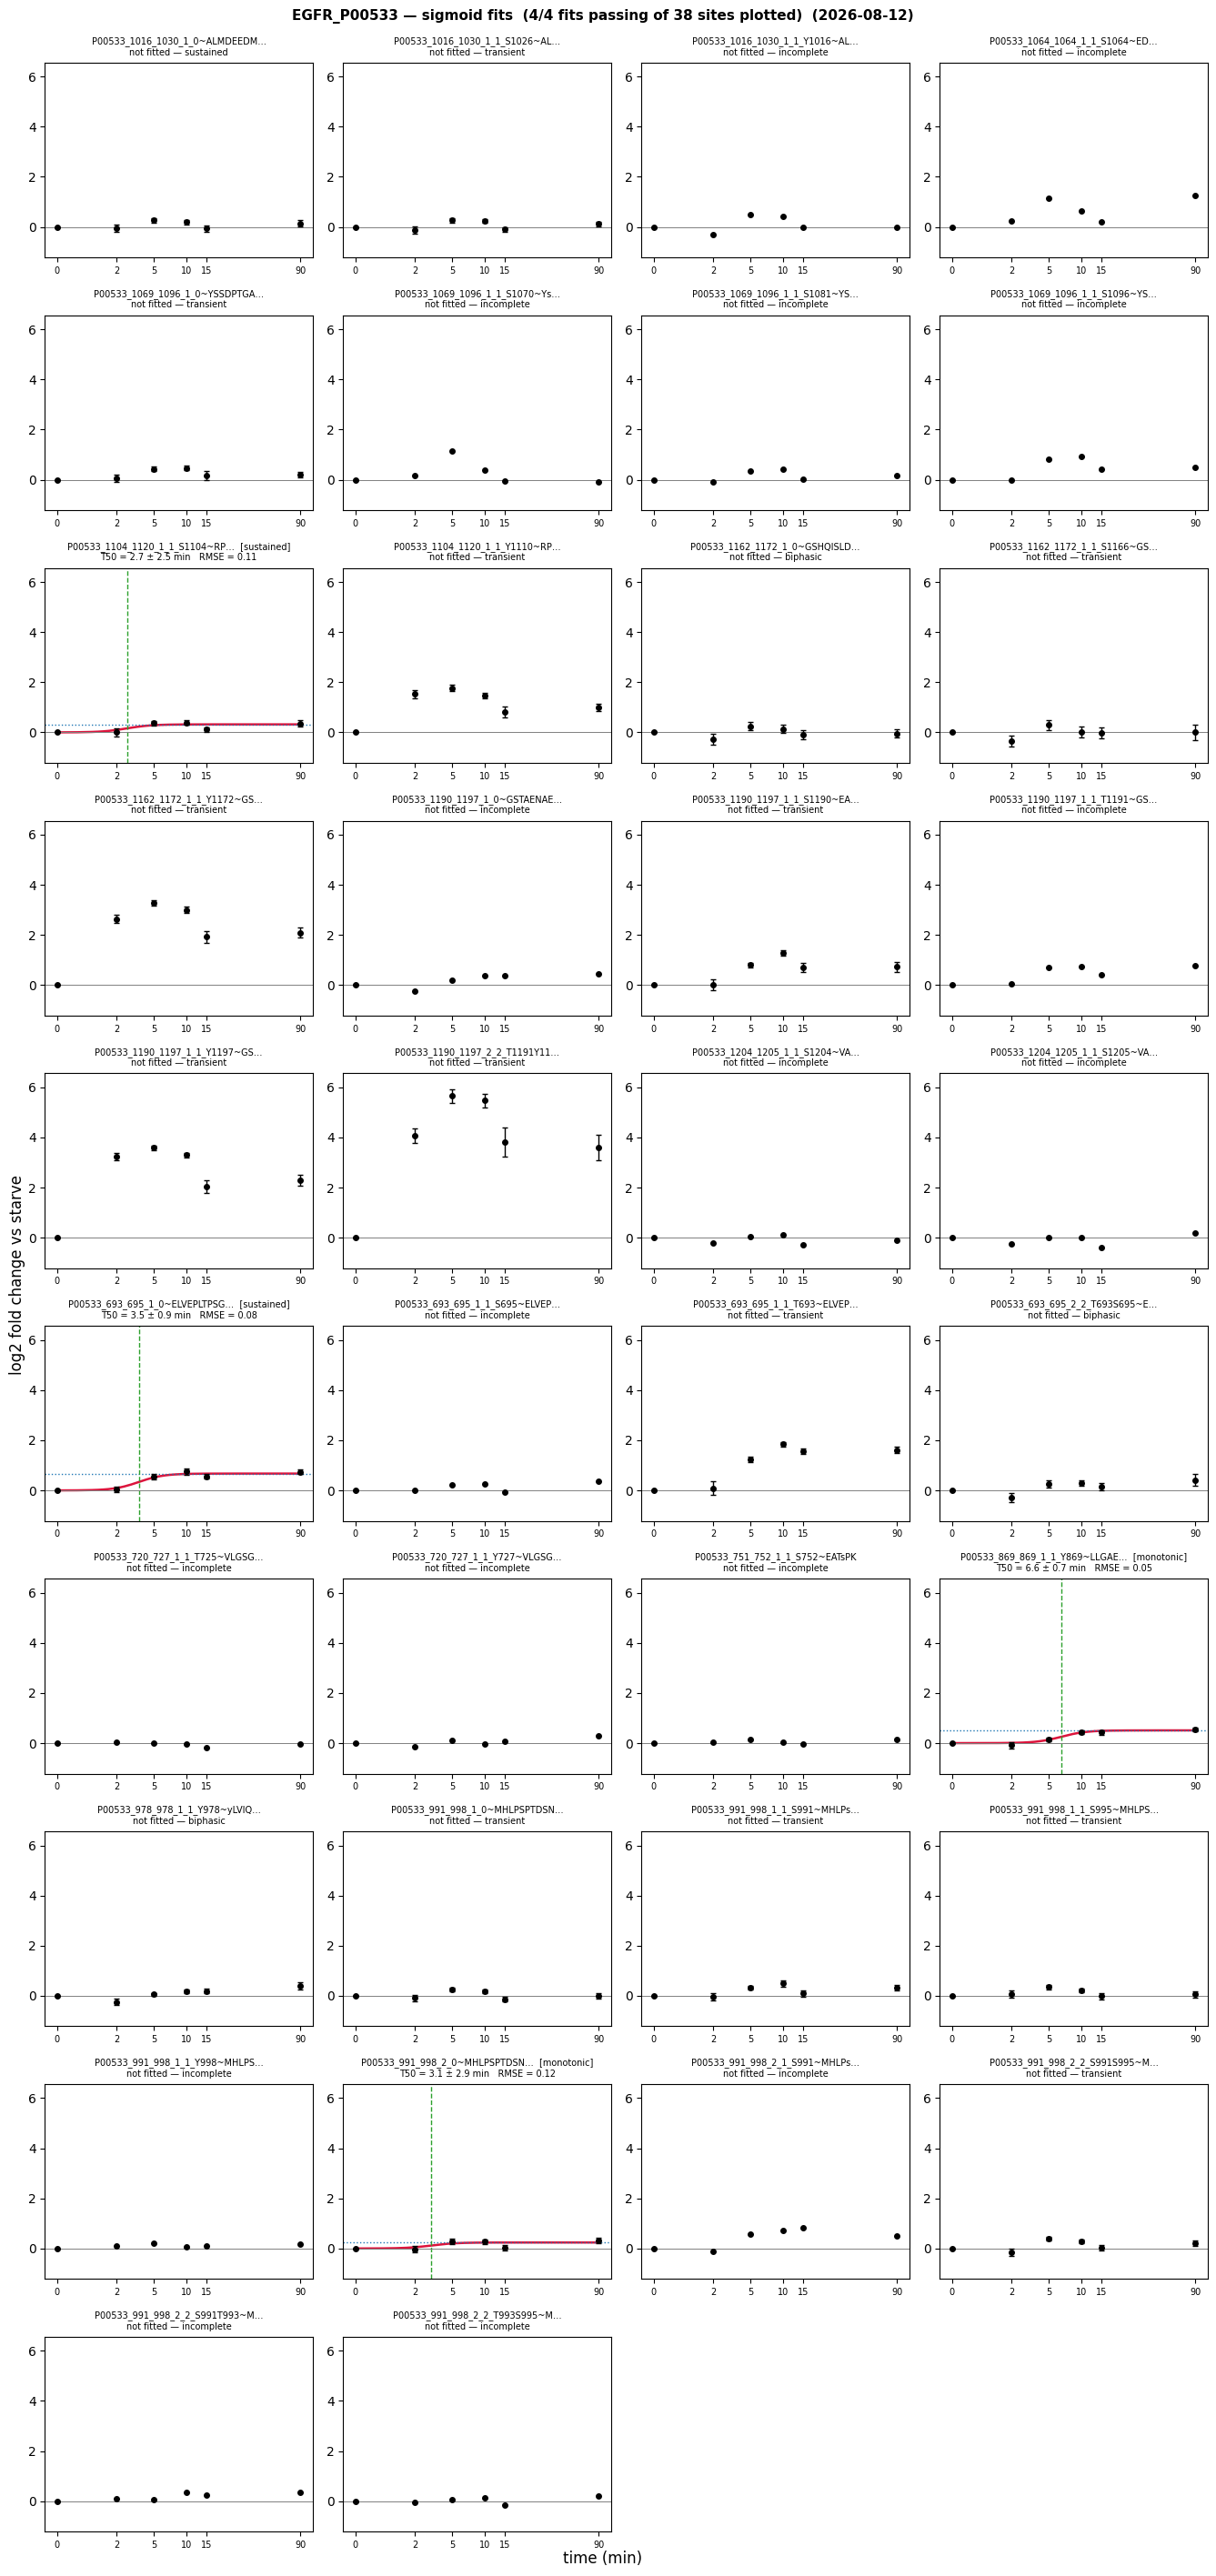

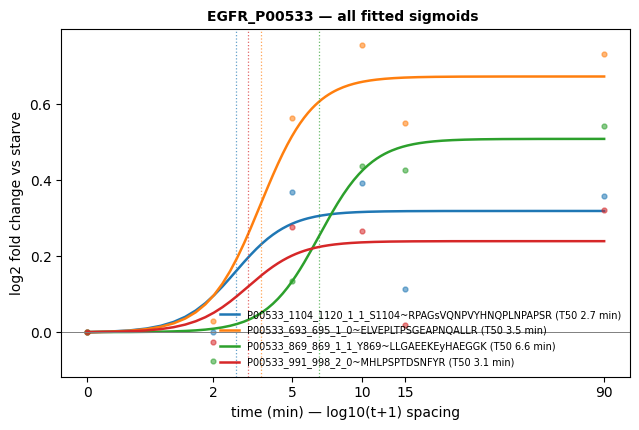

In [75]:
# One protein. `overlay=True` (default) adds the all-curves-on-one-axes figure.
PROTEIN = "EGFR"          # accepts a protein_name or a protein_Id (UniProt accession)

egfr_figs = plot_protein_sigmoid_fits(output,
                                      values_mean,
                                      times,
                                      PROTEIN,
                                      sem         = sem_fit,
                                      log_time    = LOG_TIME,
                                      value_label = FIT_LABEL,)
plt.show()

The protein SHC1 has no site left to plot with the current filters (only_passing=False, include_unfitted=False)
The protein GRB2 has no site left to plot with the current filters (only_passing=False, include_unfitted=False)
The protein SHOC2 has no site left to plot with the current filters (only_passing=False, include_unfitted=False)

Proteins with at least one fitted site: ['BRAF', 'EGFR', 'GAB1', 'MAP2K1', 'MAPK1', 'MAPK3', 'RAF1', 'RPS6KA1', 'RPS6KA3', 'SOS1']


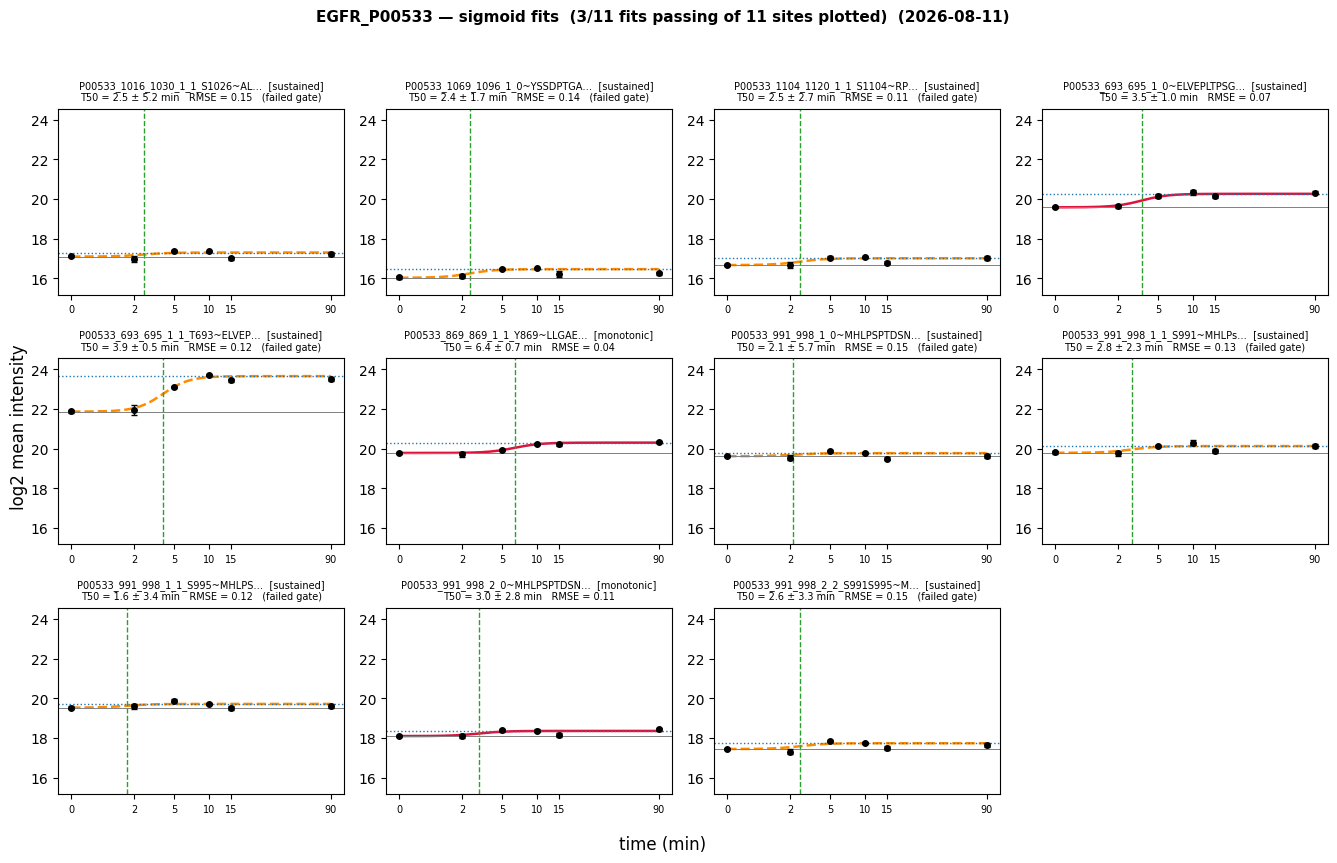

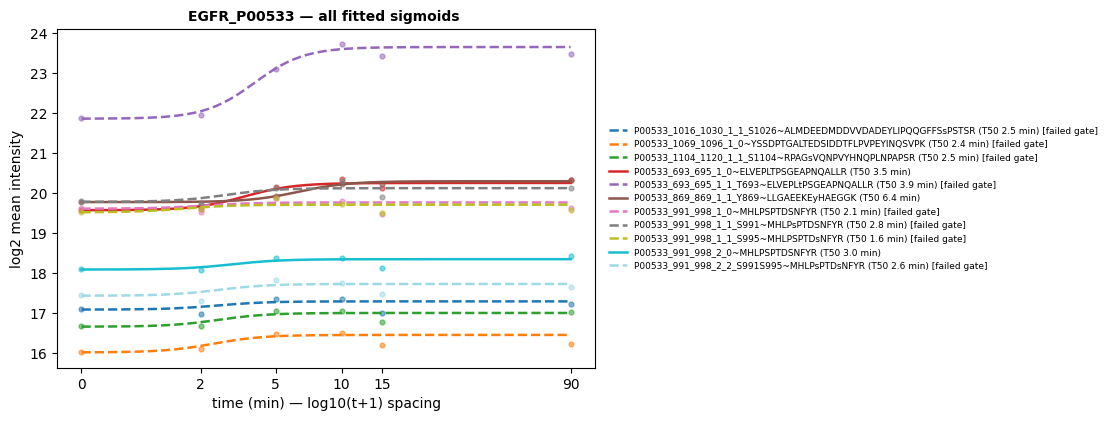

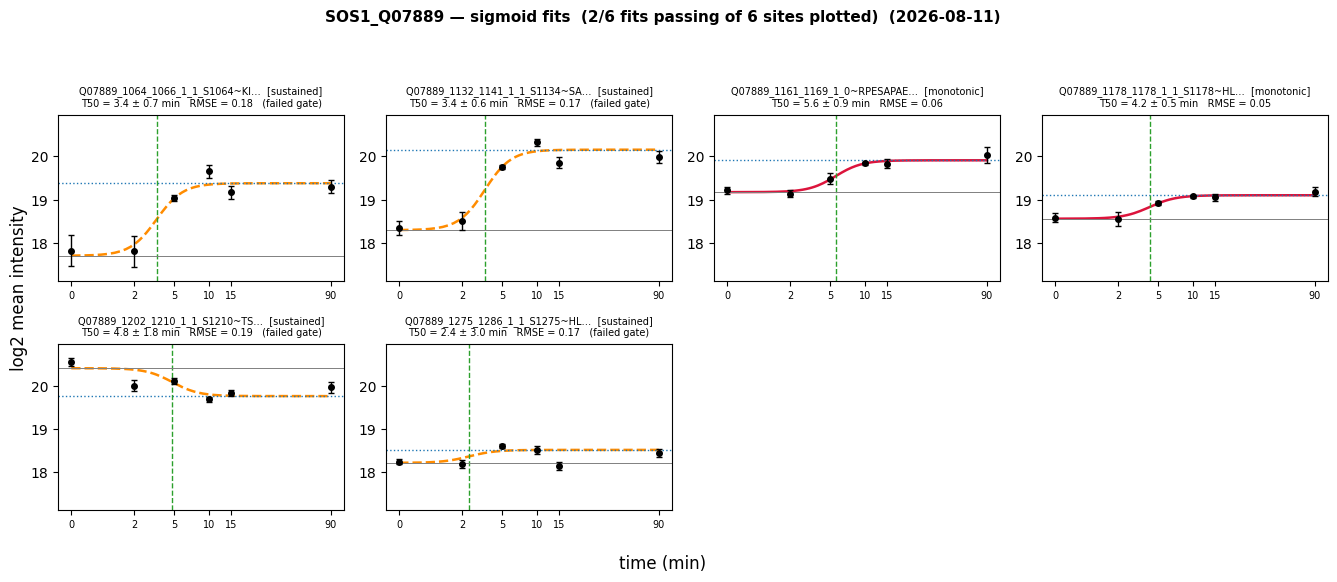

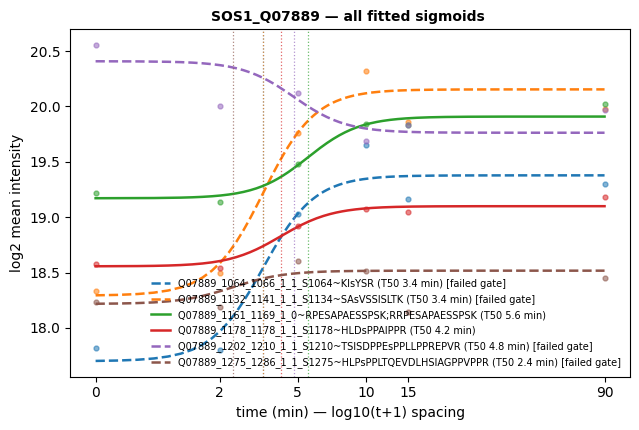

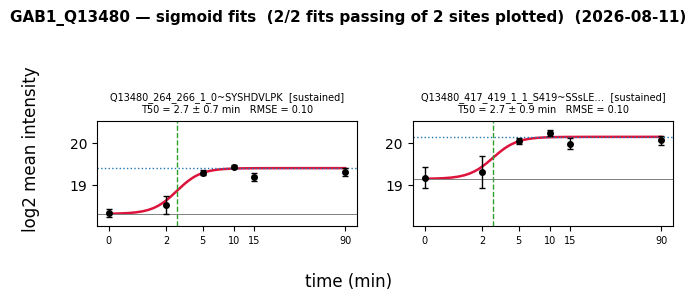

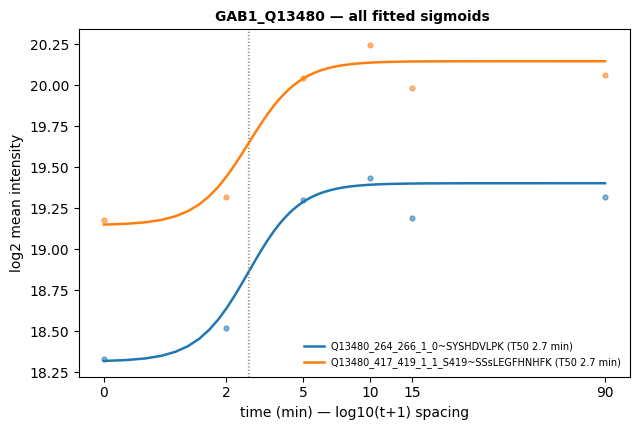

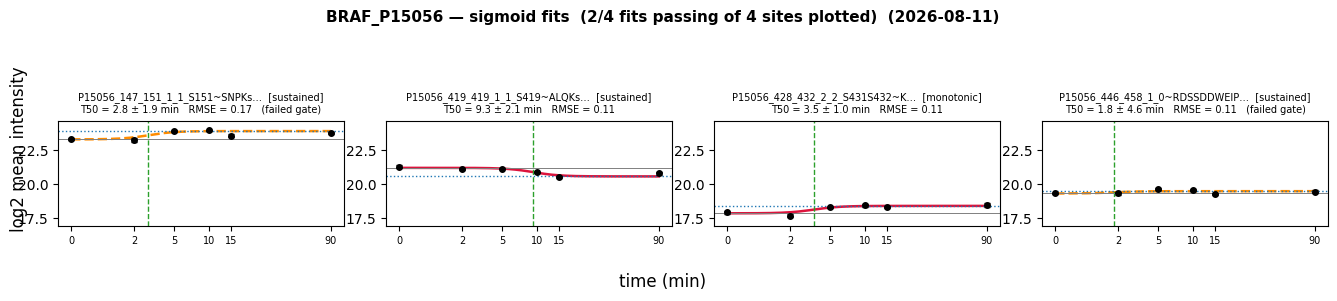

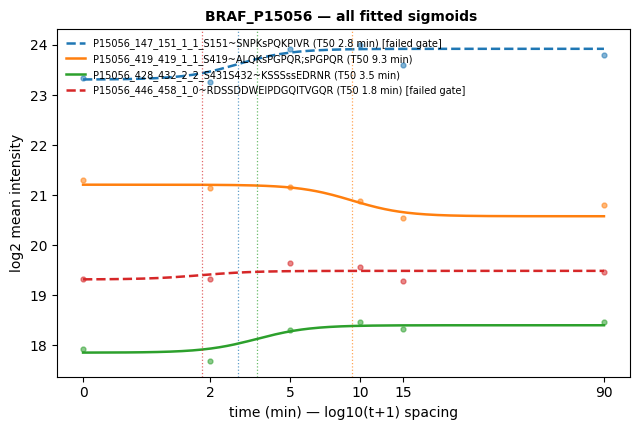

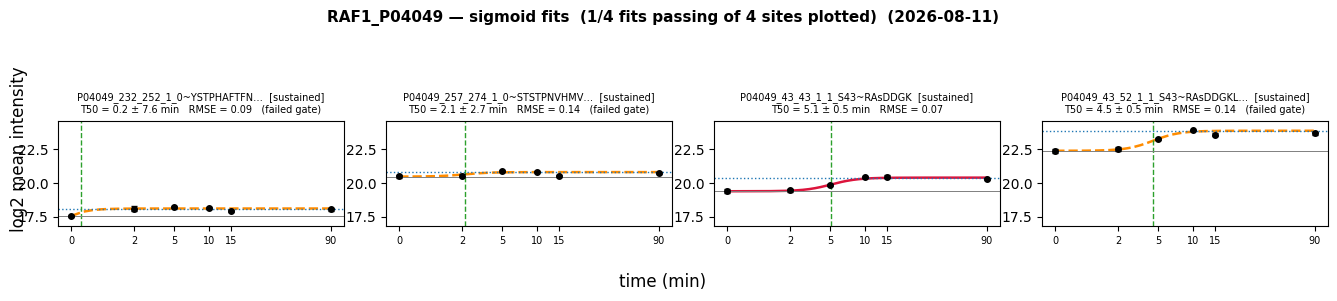

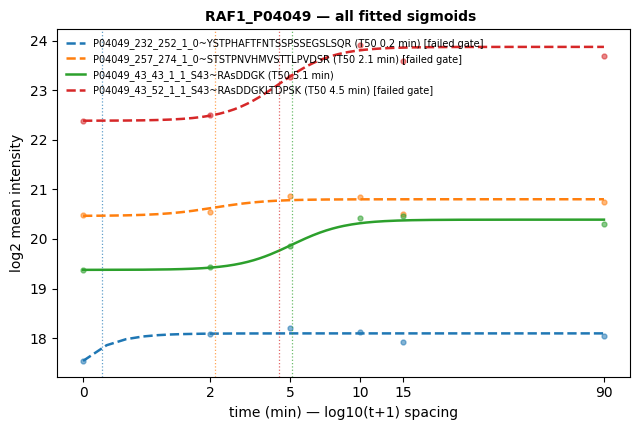

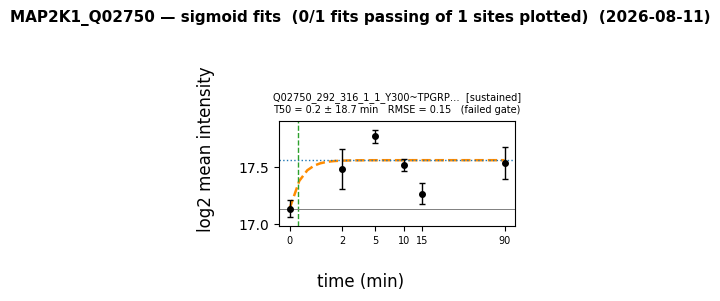

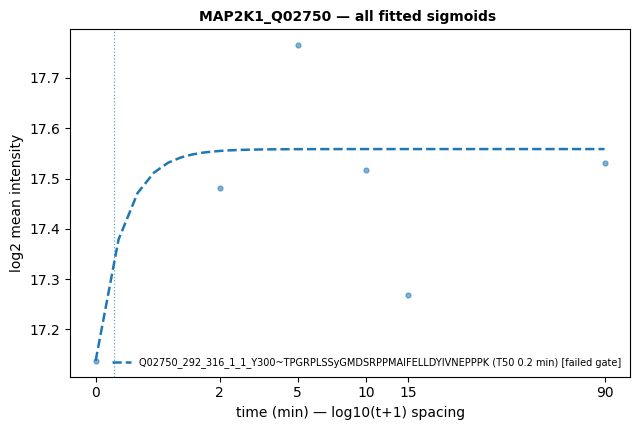

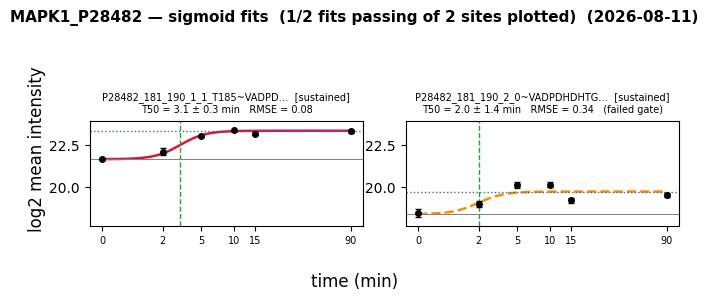

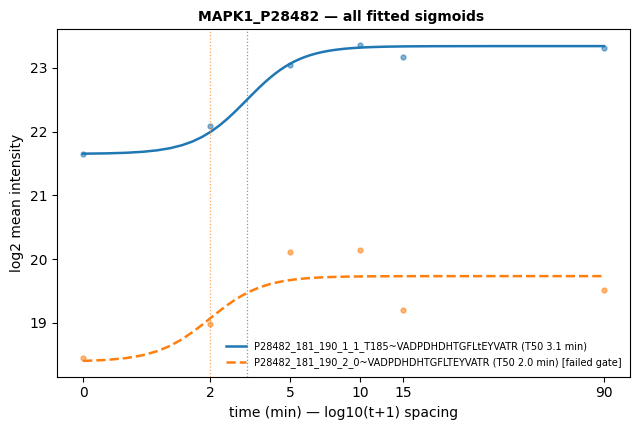

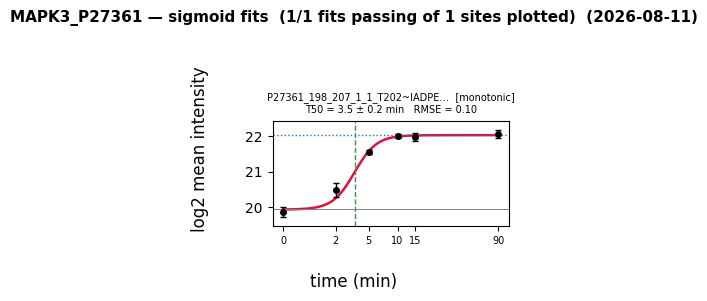

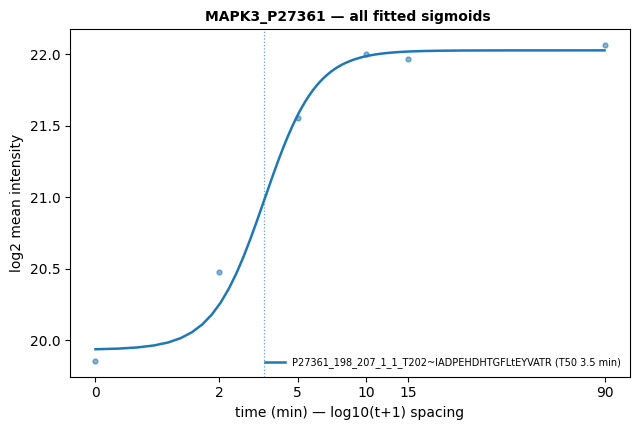

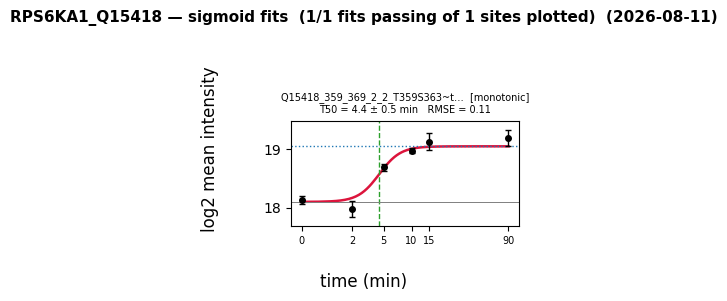

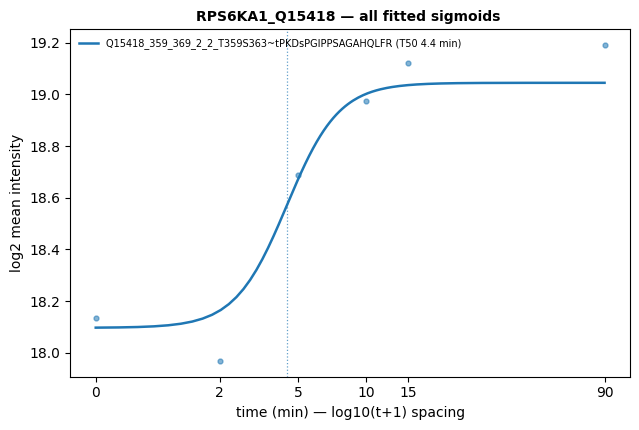

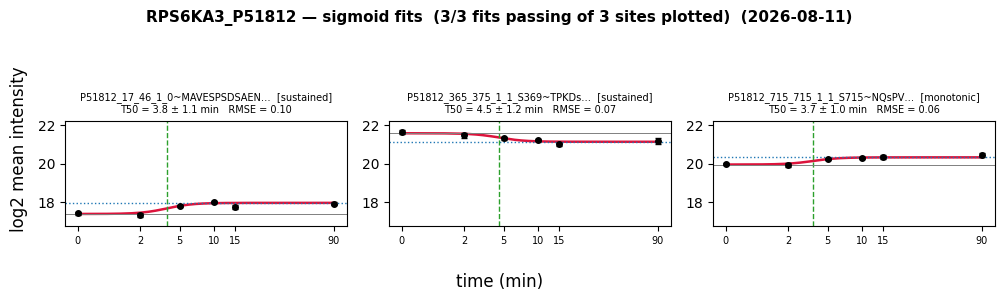

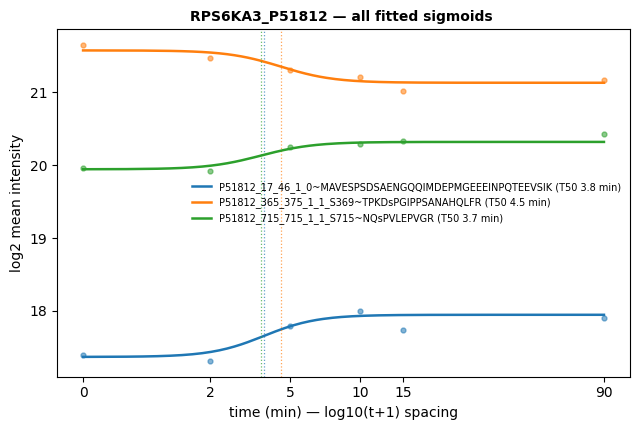

In [32]:
# A list of proteins at a time. Heavily phosphorylated proteins (SRRM2 carries 677 sites in hme1_2) are capped by `max_sites`, which keeps the passing fits first and says what it dropped.
#  include_unfitted = False  -> only the sites a sigmoid was actually fitted to
#   only_passing     = True   -> only the fits that survived every quality gate
#
# Each protein produces two figures, so the whole list opens ~26 and matplotlib warns
# past 20 — plot_close is tied to SAVE_FIGURES below, or shorten the list.
PATHWAY_PROTEINS = ["EGFR", "SOS1", "GAB1", "BRAF", "RAF1", "MAP2K1", "MAPK1", "MAPK3",
                    "SHC1", "GRB2", "SHOC2", "RPS6KA1", "RPS6KA3",]

if SAVE_FIGURES:
    os.makedirs(RESULTS_DIR, exist_ok=True,)

protein_figs = plot_protein_sigmoid_fits(output,
                                         values_mean,
                                         times,
                                         PATHWAY_PROTEINS,
                                         sem              = sem_fit,
                                         log_time         = LOG_TIME,
                                         value_label      = FIT_LABEL,
                                         include_unfitted = False,
                                         saving_path      = RESULTS_DIR if SAVE_FIGURES else "",
                                         saving_info      = RUN_NAME,
                                         save_pdf         = SAVE_FIGURES,
                                         plot_close       = SAVE_FIGURES,)

print(f"\nProteins with at least one fitted site: {sorted(protein_figs)}")

In [33]:
# The numbers behind the panels: T50 per site for the protein above, best-determined first.
_cols = ["site", "shape_class", "plateau", "t_half_min", "se_t_half", "rmse", "fit_ok",]
_tbl = output.loc[output["protein_name"] == PROTEIN, _cols]
print(_tbl.sort_values("se_t_half",).round(2,).to_string(index=False,))

                                                       site    shape_class  plateau  t_half_min  se_t_half  rmse  fit_ok
                P00533_693_695_1_1_T693~ELVEPLtPSGEAPNQALLR      sustained     1.79        3.93       0.50  0.12   False
                    P00533_869_869_1_1_Y869~LLGAEEKEyHAEGGK      monotonic     0.52        6.43       0.67  0.04    True
                     P00533_693_695_1_0~ELVEPLTPSGEAPNQALLR      sustained     0.68        3.48       0.97  0.07    True
       P00533_1069_1096_1_0~YSSDPTGALTEDSIDDTFLPVPEYINQSVPK      sustained     0.44        2.40       1.70  0.14   False
                      P00533_991_998_1_1_S991~MHLPsPTDSNFYR      sustained     0.34        2.79       2.34  0.13   False
          P00533_1104_1120_1_1_S1104~RPAGsVQNPVYHNQPLNPAPSR      sustained     0.34        2.55       2.72  0.11   False
                           P00533_991_998_2_0~MHLPSPTDSNFYR      monotonic     0.26        3.01       2.81  0.11    True
                  P00533_991_998

## Where this goes next

- **Set-level statistics on T50**, not per-site claims: overlay the kinase predictions
  (`predicted_kinase_1`) or the KSEA substrate sets from `src/kinase_activity.py` and test whether
  known-early substrate sets have a lower median T50 than known-late ones. That reconstructs the
  order of the cascade from the data alone and validates the method against textbook pathway
  topology.
- **The transient majority.** The model-free descriptors cover them, but a 3-parameter
  exponential-difference model
  `y = A * kon/(kon-koff) * (exp(-koff*t) - exp(-kon*t))` would give them a fitted peak time and
  decay half-life on the same lack-of-fit df as the sigmoid. Not implemented here.
- **Crosstalk.** Rerun with `CONDITION = "_INS_"` and `"_EGFnINS_"` and compare `(plateau, T50)`
  per site: a T50 shift with unchanged amplitude is *timing* crosstalk, an amplitude shift with
  unchanged T50 is *gain* crosstalk. Clustering cannot separate those two.
- **The impulse model** needs more timepoints than hme1_2 has, and moving to the mean scale does
  **not** rescue it: 6 points against 5 parameters is 1 lack-of-fit df, still untestable, and on
  5 informative points it has zero and interpolates any site including pure noise. It becomes
  identifiable on the 9-timepoint hme1_lfq design. If a parametric transient model is revisited
  before then, the only defensible route is the `fixed_k` pattern used here — fit the shared
  shape parameters globally, fix them, leave 2–3 free per site.
- **Replicate-level fitting.** Fitting `log2:abs` per replicate instead of the condition means
  would use the replicate structure directly rather than through a weight. Considered and
  deliberately deferred: it changes the error model everywhere downstream, and the soft anchor
  already recovers the part of it that mattered (the starve replicates now do work).
- **Upstream:** the loading normalisation. Until it is fixed in `src/transformations.py`, the
  as-stored and median-centred censuses above bracket the answer rather than settling it. Note
  that `center_timepoint_medians` is a **fold-change-space** stand-in only — on the mean scale the
  loading shift is an absolute level offset and removing the across-site median would also remove
  the real site-to-site spread in baseline abundance, which is what `y0` is fitted to.